# Taller B4-T1 — Diseño de Redes Confiables

**Componentes del equipo:**

- Albert Martin
- Josep Pérez Segura
- Rodolfo Villena

**Práctica:** Diseño de redes confiables para clasificación de riesgo de crédito.

**Bloques implementados en esta versión:**

1. Arquitectura customizada mediante una capa financiera `DebtBurdenLayer`.
2. Aprendizaje justo mediante funciones de pérdida FAIR que penalizan la dependencia entre las predicciones y la variable sensible `CODE_GENDER`.

El objetivo de este notebook es construir, entrenar y auditar un modelo de clasificación binaria para riesgo de crédito, incorporando restricciones financieras explícitas y una primera estrategia de reducción de dependencia estadística respecto al género.

Vamos a trabajar con el dataset `application_train.csv` de Home Credit Default Risk y construiremos un modelo binario para predecir `TARGET`:

- `TARGET = 1`: cliente con dificultades de pago.
- `TARGET = 0`: cliente sin dificultades de pago.

Este notebook integra los dos primeros bloques de la práctica:

1. una arquitectura customizada basada en ratios financieros calculados por `DebtBurdenLayer`;
2. una extensión de aprendizaje justo mediante funciones de pérdida customizadas que penalizan la dependencia estadística entre las predicciones y `CODE_GENDER`.

La capa `DebtBurdenLayer` calcula dentro del modelo dos indicadores financieros interpretables:

- cuota anual sobre ingresos: `AMT_ANNUITY / AMT_INCOME_TOTAL`;
- crédito total sobre ingresos: `AMT_CREDIT / AMT_INCOME_TOTAL`.

Estos ratios se calculan con variables monetarias en bruto, no con variables escaladas, para conservar su significado económico.

In [18]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

DATA_PATH_CANDIDATES = [Path("data") / "application_train.csv", Path("application_train.csv")]
DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), DATA_PATH_CANDIDATES[0])
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## Por qué no usamos `CODE_GENDER` como entrada

`CODE_GENDER` se trata como **variable sensible**. La guardamos aparte porque será necesaria para auditar diferencias entre grupos y, más adelante, para diseñar o evaluar restricciones de justicia.

En esta primera arquitectura no se incluye como entrada directa del modelo. De este modo evitamos que la red utilice explícitamente el género para optimizar la predicción. Esto no garantiza justicia por sí solo, porque otras variables pueden contener información correlacionada con el género, pero deja preparada una separación clara entre:

- variables predictoras usadas por la red;
- variable sensible usada para auditoría y futuras pérdidas FAIR.

## Carga y preprocesado de datos

La función `load_home_credit_data` realiza un preprocesado cuidadoso y evita fugas de información entre entrenamiento, validación y test:

- lee únicamente las columnas necesarias para este punto;
- elimina los casos `CODE_GENDER == "XNA"`;
- convierte `CODE_GENDER` a una variable binaria sensible (`M -> 0`, `F -> 1`);
- transforma `DAYS_BIRTH` en edad positiva en años;
- separa `y`, `s` y las variables de entrada del modelo;
- crea dos ramas de entrada: una escalada y otra financiera en bruto;
- separa explícitamente `train`, `validation` y `test`;
- ajusta imputador y escalador solo con `train`;
- aplica esas transformaciones a `validation` y `test` sin recalcular parámetros.

In [19]:
def load_home_credit_data(file_path):
    """Carga y prepara los datos de Home Credit para la arquitectura customizada.

    La función devuelve tres subconjuntos separados: train, validation y test.
    Cada subconjunto contiene:
    1. variables predictoras imputadas y escaladas;
    2. variables financieras imputadas en bruto, sin escalar;
    3. etiqueta binaria `TARGET` en formato float32 para Keras;
    4. variable sensible `CODE_GENDER` conservada aparte para auditoría.

    La rama financiera se mantiene en escala monetaria real porque los ratios de
    `DebtBurdenLayer` deben calcularse sobre importes originales o imputados, no
    sobre z-scores.
    """

    selected_cols = [
        "TARGET",
        "CODE_GENDER",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "DAYS_BIRTH",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
    ]

    df = pd.read_csv(file_path, usecols=selected_cols)
    df = df.loc[df["CODE_GENDER"] != "XNA"].copy()

    # Flags de missingness calculados antes de imputar. No entran todavía como
    # inputs del modelo, pero quedan disponibles para incertidumbre y auditoría.
    ext_source_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    missing_flag_cols = [f"{col}_missing" for col in ext_source_cols]
    ext_source_missing_flags = df[ext_source_cols].isna().astype("int32")
    ext_source_missing_flags.columns = missing_flag_cols

    ext_source_missingness_summary = pd.DataFrame(
        {
            "variable": ext_source_cols,
            "missing_count": df[ext_source_cols].isna().sum().to_numpy(),
            "missing_rate": df[ext_source_cols].isna().mean().to_numpy(),
        }
    )

    # Variable sensible codificada y conservada fuera del input del modelo.
    df["CODE_GENDER"] = df["CODE_GENDER"].map({"M": 0, "F": 1}).astype(int)

    # Edad positiva en años. La columna original se elimina para evitar duplicar
    # la misma información con dos escalas distintas.
    df["AGE_YEARS"] = np.abs(df["DAYS_BIRTH"]) / 365.25
    df = df.drop(columns=["DAYS_BIRTH"])

    scaled_features = [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AGE_YEARS",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
    ]
    financial_features = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]

    X = df[scaled_features].copy()
    y = df["TARGET"].astype(int)
    s = df["CODE_GENDER"].astype(int)

    # Primer split: separamos test y no lo tocamos durante entrenamiento ni
    # selección de hiperparámetros.
    (
        X_trainval,
        X_test,
        missing_trainval,
        missing_test,
        y_trainval,
        y_test,
        s_trainval,
        s_test,
    ) = train_test_split(
        X,
        ext_source_missing_flags,
        y,
        s,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    # Segundo split: separamos validation desde trainval. El reparto final queda
    # aproximadamente en 64 % train, 16 % validation y 20 % test.
    (
        X_train,
        X_val,
        missing_train,
        missing_val,
        y_train,
        y_val,
        s_train,
        s_val,
    ) = train_test_split(
        X_trainval,
        missing_trainval,
        y_trainval,
        s_trainval,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_trainval,
    )

    # Imputación ajustada solo con train. Validation y test se transforman con el
    # mismo imputador para evitar data leakage.
    imputer = SimpleImputer(strategy="median")
    X_train_imputed = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index,
    )
    X_val_imputed = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index,
    )
    X_test_imputed = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index,
    )

    # Rama financiera: datos imputados, pero no escalados. Así los ratios internos
    # siguen teniendo interpretación económica.
    X_train_financial_raw = X_train_imputed[financial_features].astype("float32")
    X_val_financial_raw = X_val_imputed[financial_features].astype("float32")
    X_test_financial_raw = X_test_imputed[financial_features].astype("float32")

    # Rama principal: escalado ajustado solo con train.
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_imputed[scaled_features]),
        columns=scaled_features,
        index=X_train_imputed.index,
    )
    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val_imputed[scaled_features]),
        columns=scaled_features,
        index=X_val_imputed.index,
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_imputed[scaled_features]),
        columns=scaled_features,
        index=X_test_imputed.index,
    )

    X_train_scaled_np = X_train_scaled.astype("float32")
    X_val_scaled_np = X_val_scaled.astype("float32")
    X_test_scaled_np = X_test_scaled.astype("float32")

    y_train_np = y_train.astype("float32").values
    y_val_np = y_val.astype("float32").values
    y_test_np = y_test.astype("float32").values

    preprocessor = {
        "feature_cols": scaled_features,
        "financial_cols": financial_features,
        "imputer": imputer,
        "medians": pd.Series(imputer.statistics_, index=scaled_features),
        "scaler": scaler,
        "missing_flag_cols": missing_flag_cols,
        "ext_source_missing_train": missing_train.reset_index(drop=True),
        "ext_source_missing_val": missing_val.reset_index(drop=True),
        "ext_source_missing_test": missing_test.reset_index(drop=True),
        "ext_source_missingness_summary": ext_source_missingness_summary,
    }

    return (
        X_train_scaled_np,
        X_train_financial_raw,
        y_train_np,
        s_train,
    ), (
        X_val_scaled_np,
        X_val_financial_raw,
        y_val_np,
        s_val,
    ), (
        X_test_scaled_np,
        X_test_financial_raw,
        y_test_np,
        s_test,
    ), preprocessor

## Split explícito train / validation / test

En esta versión sustituimos la partición automática de validación por un conjunto de validación explícito. Esto permite conservar también la variable sensible `CODE_GENDER` en validación (`s_val`), lo cual será necesario para la siguiente fase de la práctica: medir y penalizar la dependencia entre las predicciones del modelo y la variable sensible.

El conjunto de test se mantiene separado y no se usa durante el entrenamiento ni durante la selección de hiperparámetros.

Antes de entrenar el modelo conviene comprobar que las ramas tienen las formas esperadas y que las distribuciones principales se conservan tras el split.

In [20]:
(
    X_train_scaled_np,
    X_train_financial_raw,
    y_train_np,
    s_train,
), (
    X_val_scaled_np,
    X_val_financial_raw,
    y_val_np,
    s_val,
), (
    X_test_scaled_np,
    X_test_financial_raw,
    y_test_np,
    s_test,
), preprocessor = load_home_credit_data(DATA_PATH)

print("Shape de X_train_scaled_np:", X_train_scaled_np.shape)
print("Shape de X_val_scaled_np:", X_val_scaled_np.shape)
print("Shape de X_test_scaled_np:", X_test_scaled_np.shape)
print("Shape de X_train_financial_raw:", X_train_financial_raw.shape)
print("Shape de X_val_financial_raw:", X_val_financial_raw.shape)
print("Shape de X_test_financial_raw:", X_test_financial_raw.shape)
print("Shape de y_train_np:", y_train_np.shape)
print("Shape de y_val_np:", y_val_np.shape)
print("Shape de y_test_np:", y_test_np.shape)

print("\ns_train shape:", s_train.shape)
print("s_val shape:", s_val.shape)
print("s_test shape:", s_test.shape)

print("\nColumnas de la rama escalada:")
print(preprocessor["feature_cols"])

print("\nColumnas de la rama financiera en bruto:")
print(preprocessor["financial_cols"])

print("\nFlags de missingness preparados para análisis posterior:")
print(preprocessor["missing_flag_cols"])

missingness_path = OUTPUT_DIR / "ext_source_missingness_summary.csv"
preprocessor["ext_source_missingness_summary"].to_csv(missingness_path, index=False)
print(f"\nResumen de missingness guardado en: {missingness_path}")
display(preprocessor["ext_source_missingness_summary"])

Shape de X_train_scaled_np: (196804, 7)
Shape de X_val_scaled_np: (49201, 7)
Shape de X_test_scaled_np: (61502, 7)
Shape de X_train_financial_raw: (196804, 3)
Shape de X_val_financial_raw: (49201, 3)
Shape de X_test_financial_raw: (61502, 3)
Shape de y_train_np: (196804,)
Shape de y_val_np: (49201,)
Shape de y_test_np: (61502,)

s_train shape: (196804,)
s_val shape: (49201,)
s_test shape: (61502,)

Columnas de la rama escalada:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AGE_YEARS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

Columnas de la rama financiera en bruto:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

Flags de missingness preparados para análisis posterior:
['EXT_SOURCE_1_missing', 'EXT_SOURCE_2_missing', 'EXT_SOURCE_3_missing']

Resumen de missingness guardado en: outputs\ext_source_missingness_summary.csv


,variable,missing_count,missing_rate
0,EXT_SOURCE_1,173376,0.563812
1,EXT_SOURCE_2,660,0.002146
2,EXT_SOURCE_3,60965,0.198256


In [21]:
# Distribución de TARGET en train, validation y test. normalize=True muestra
# proporciones, útil porque el problema está desbalanceado hacia la clase 0.
print("Distribución de TARGET en train:")
print(pd.Series(y_train_np, name="TARGET").value_counts(normalize=True).sort_index())

print("\nDistribución de TARGET en validation:")
print(pd.Series(y_val_np, name="TARGET").value_counts(normalize=True).sort_index())

print("\nDistribución de TARGET en test:")
print(pd.Series(y_test_np, name="TARGET").value_counts(normalize=True).sort_index())

# Distribución de la variable sensible. Esta información no se usa como input
# del modelo, pero se conserva para los siguientes puntos de justicia.
print("\nDistribución de CODE_GENDER en train (0=M, 1=F):")
print(s_train.value_counts(normalize=True).sort_index())

print("\nDistribución de CODE_GENDER en validation (0=M, 1=F):")
print(s_val.value_counts(normalize=True).sort_index())

print("\nDistribución de CODE_GENDER en test (0=M, 1=F):")
print(s_test.value_counts(normalize=True).sort_index())

Distribución de TARGET en train:
TARGET
0.0    0.91927
1.0    0.08073
Name: proportion, dtype: float64

Distribución de TARGET en validation:
TARGET
0.0    0.91927
1.0    0.08073
Name: proportion, dtype: float64

Distribución de TARGET en test:
TARGET
0.0    0.919271
1.0    0.080729
Name: proportion, dtype: float64

Distribución de CODE_GENDER en train (0=M, 1=F):
CODE_GENDER
0    0.341939
1    0.658061
Name: proportion, dtype: float64

Distribución de CODE_GENDER en validation (0=M, 1=F):
CODE_GENDER
0    0.341578
1    0.658422
Name: proportion, dtype: float64

Distribución de CODE_GENDER en test (0=M, 1=F):
CODE_GENDER
0    0.340769
1    0.659231
Name: proportion, dtype: float64


### Interpretación del desbalance de clases

La variable objetivo está fuertemente desbalanceada. Aproximadamente el 92 % de los clientes pertenecen a la clase `TARGET = 0` y solo alrededor del 8 % pertenecen a la clase `TARGET = 1`.

Esto implica que la métrica `accuracy` debe interpretarse con cautela. Un modelo trivial que predijera siempre “buen pagador” obtendría una accuracy muy alta, pero no detectaría ningún cliente con dificultades de pago.

Por este motivo, en este problema son especialmente relevantes métricas como AUC, recall de la clase minoritaria, precision de la clase minoritaria y balanced accuracy.

In [22]:
# Primeras filas de la rama financiera en bruto. Deben verse como importes
# monetarios originales, no como variables centradas alrededor de cero.
X_train_financial_raw.head(10)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
1228,90000.0,203760.0,11826.0
162360,67500.0,180000.0,9000.0
68610,315000.0,1125000.0,44019.0
122818,225000.0,156384.0,16155.0
274639,135000.0,573628.5,24435.0
154292,211500.0,729567.0,27166.5
290325,180000.0,113076.0,5773.5
176690,112500.0,381528.0,22032.0
156479,67500.0,343800.0,16155.0
212749,121500.0,942300.0,30528.0


## Por qué calculamos ratios financieros en una capa customizada

Una red densa estándar puede aprender interacciones entre variables, pero no sabe de partida que ciertos cocientes financieros son especialmente relevantes.

La capa customizada introduce conocimiento previo del dominio:

- una cuota anual alta respecto a ingresos puede indicar mayor presión financiera;
- un crédito alto respecto a ingresos puede indicar mayor exposición al endeudamiento.

Al calcular estos ratios dentro del grafo de TensorFlow, la transformación queda integrada en el modelo, aparece en `model.summary()` y puede serializarse junto con la arquitectura.

## Flags de missingness para `EXT_SOURCE`

Las variables `EXT_SOURCE_1`, `EXT_SOURCE_2` y `EXT_SOURCE_3` tienen valores ausentes. En este punto los valores se imputan con medianas calculadas solo en train, pero además conservamos tres indicadores auxiliares:

- `EXT_SOURCE_1_missing`;
- `EXT_SOURCE_2_missing`;
- `EXT_SOURCE_3_missing`.

Estos flags valen 1 si el dato original estaba ausente y 0 si estaba informado. No se usan todavía como entrada de la arquitectura principal, pero quedan preparados para el análisis posterior de incertidumbre. El resumen de missingness se guarda en `outputs/ext_source_missingness_summary.csv`.

## Por qué se usa `tanh` como saturación

Los ratios financieros pueden tomar valores extremos cuando los ingresos son bajos o cuando el crédito es muy alto. Si se pasan directamente a la red, esos valores pueden dominar el entrenamiento.

Usamos `tanh` porque es una saturación suave y diferenciable:

- mantiene el entrenamiento compatible con backpropagation;
- comprime valores extremos;
- conserva una señal ordenada: ratios más altos producen salidas saturadas más altas;
- reduce el impacto de outliers sin aplicar cortes bruscos.

### Interpretación de la capa `DebtBurdenLayer`

La capa customizada introduce conocimiento financiero dentro de la arquitectura neuronal.

En lugar de dejar que la red aprenda desde cero todas las relaciones entre ingresos, crédito y anualidad, calculamos explícitamente dos ratios interpretables:

- cuota anual sobre ingresos;
- crédito total sobre ingresos.

Después aplicamos una saturación suave mediante `tanh`. Esta saturación evita que ratios extremos dominen el entrenamiento, pero conserva el orden económico de la señal: ratios más altos siguen generando valores más altos.

La capa no tiene parámetros entrenables. Su función es imponer una transformación financiera razonable antes de pasar la información a las capas densas.

In [23]:
class DebtBurdenLayer(tf.keras.layers.Layer):
    """Capa customizada para calcular ratios de endeudamiento saturados.

    La capa recibe tres columnas en este orden:
    [AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY]

    Devuelve dos columnas:
    1. `annuity_ratio_sat`: cuota anual sobre ingresos, saturada con tanh.
    2. `credit_ratio_sat`: crédito total sobre ingresos, saturado con tanh.
    """

    def __init__(self, annuity_tau=0.5, credit_tau=5.0, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.annuity_tau = annuity_tau
        self.credit_tau = credit_tau
        self.epsilon = epsilon

    def call(self, inputs):
        # Separación explícita de columnas. Usamos rangos como 0:1 para mantener
        # tensores bidimensionales de shape (batch_size, 1), lo que facilita la
        # concatenación posterior.
        income = inputs[:, 0:1]
        credit = inputs[:, 1:2]
        annuity = inputs[:, 2:3]

        # Ratios financieros sobre variables monetarias originales. epsilon evita
        # divisiones por cero si apareciera algún ingreso nulo.
        annuity_income_ratio = annuity / (income + self.epsilon)
        credit_income_ratio = credit / (income + self.epsilon)

        # Saturación suave. Los parámetros tau controlan la escala a partir de la
        # cual cada ratio empieza a acercarse a 1.
        annuity_ratio_sat = tf.math.tanh(annuity_income_ratio / self.annuity_tau)
        credit_ratio_sat = tf.math.tanh(credit_income_ratio / self.credit_tau)

        # El resultado final tiene dos columnas y puede concatenarse con la rama
        # principal de variables escaladas.
        return tf.concat([annuity_ratio_sat, credit_ratio_sat], axis=1)

    def get_config(self):
        # Permite guardar y recargar modelos que incluyan esta capa customizada.
        config = super().get_config()
        config.update(
            {
                "annuity_tau": self.annuity_tau,
                "credit_tau": self.credit_tau,
                "epsilon": self.epsilon,
            }
        )
        return config

## Comprobación de la capa customizada

Probamos `DebtBurdenLayer` sobre cinco ejemplos reales de la rama financiera. La salida debe tener dos columnas y valores aproximadamente entre 0 y 1, porque los importes son positivos y `tanh` satura por arriba.

In [24]:
# Instanciamos la capa de forma aislada para verificar su comportamiento antes
# de integrarla en el modelo funcional.
debt_layer_check = DebtBurdenLayer(name="debt_burden_layer_check")
ratio_examples = debt_layer_check(X_train_financial_raw.iloc[:5].to_numpy()).numpy()

ratio_check_df = pd.DataFrame(
    ratio_examples,
    columns=["annuity_ratio_sat", "credit_ratio_sat"],
)

print("Shape de la salida de DebtBurdenLayer:", ratio_examples.shape)
print("\nPrimeros ratios saturados:")
display(ratio_check_df)

print("\nMínimos por columna:")
print(ratio_check_df.min())

print("\nMáximos por columna:")
print(ratio_check_df.max())

Shape de la salida de DebtBurdenLayer: (5, 2)

Primeros ratios saturados:


,annuity_ratio_sat,credit_ratio_sat
0,0.256913,0.424198
1,0.260520,0.487925
2,0.272429,0.613357
3,0.142621,0.138120
4,0.346974,0.690975



Mínimos por columna:
annuity_ratio_sat    0.142621
credit_ratio_sat     0.138120
dtype: float32

Máximos por columna:
annuity_ratio_sat    0.346974
credit_ratio_sat     0.690975
dtype: float32


## Modelo funcional con dos entradas

La red tiene dos ramas de entrada:

- `scaled_features`: siete variables imputadas y escaladas;
- `financial_raw`: tres variables monetarias imputadas sin escalar.

La capa `DebtBurdenLayer` transforma la rama financiera en dos ratios saturados. Después concatenamos esos dos ratios con las siete variables escaladas y entrenamos capas densas para la clasificación binaria.

In [25]:
def build_custom_debt_model(n_scaled_features):
    """Construye el modelo Keras funcional con la capa DebtBurdenLayer."""

    # Entrada principal: variables numéricas ya imputadas y estandarizadas.
    scaled_input = keras.Input(
        shape=(n_scaled_features,),
        name="scaled_features",
    )

    # Entrada financiera: importes originales imputados, sin escalar. Esta rama
    # existe exclusivamente para calcular ratios interpretables dentro del modelo.
    financial_raw_input = keras.Input(
        shape=(3,),
        name="financial_raw",
    )

    # Capa customizada solicitada en la práctica. Debe aparecer en model.summary().
    ratios = DebtBurdenLayer(name="debt_burden_layer")(financial_raw_input)

    # Unimos las variables escaladas con los ratios financieros calculados por
    # la red. El tensor resultante tiene 7 + 2 = 9 variables.
    x = layers.Concatenate(name="concat_scaled_and_custom_ratios")(
        [scaled_input, ratios]
    )

    # Bloque denso sencillo. BatchNormalization ayuda a estabilizar activaciones
    # intermedias; Dropout reduce sobreajuste en una tabla con muchas filas.
    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    x = layers.BatchNormalization(name="batch_norm_64")(x)
    x = layers.Dropout(0.25, name="dropout_025")(x)

    x = layers.Dense(32, activation="relu", name="dense_32")(x)
    x = layers.Dropout(0.15, name="dropout_015")(x)

    # Salida binaria: probabilidad estimada de TARGET = 1.
    output = layers.Dense(1, activation="sigmoid", name="default_probability")(x)

    model = keras.Model(
        inputs=[scaled_input, financial_raw_input],
        outputs=output,
        name="home_credit_custom_debt_model",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )

    return model


tf.keras.backend.clear_session()
keras.utils.set_random_seed(RANDOM_STATE)

model = build_custom_debt_model(n_scaled_features=X_train_scaled_np.shape[1])
model.summary()

Model: "home_credit_custom_debt_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ financial_raw       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scaled_features     │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ debt_burden_layer   │ (None, 2)         │          0 │ financial_raw[0]… │
│ (DebtBurdenLayer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_scaled_and_… │ (None, 9)         │          0 │ scaled_features[… │
│ (Concatenate)       │                   │            │ debt_burden_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │        640 │ concat_scaled_an… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm_64       │ (None, 64)        │        256 │ dense_64[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_025         │ (None, 64)        │          0 │ batch_norm_64[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 32)        │      2,080 │ dropout_025[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_015         │ (None, 32)        │          0 │ dense_32[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ default_probability │ (None, 1)         │         33 │ dropout_015[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 128 (512.00 B)

## Entrenamiento

`TARGET` está desbalanceada: hay muchos más buenos pagadores que clientes con dificultades. Para compensarlo, calculamos `class_weight` con sklearn y lo pasamos a `model.fit`.

También usamos dos callbacks:

- `EarlyStopping`, para recuperar los mejores pesos según `val_auc`;
- `ReduceLROnPlateau`, para reducir la tasa de aprendizaje si `val_auc` deja de mejorar.

In [26]:
# Pesos de clase calculados solo con y_train. El objetivo es que la clase
# minoritaria tenga más peso durante la optimización.
classes = np.unique(y_train_np.astype(int))
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_np.astype(int),
)

# Conversión explícita a tipos nativos de Python para evitar impresiones como
# np.int64(0) o np.float64(...), y para mantener compatibilidad clara con Keras.
class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_values)
}

print("Class weights:", class_weight)

EPOCHS = 300  # techo alto; el early stopping (paciencia amplia) decide el corte real
BATCH_SIZE = 1024

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=40,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=12,
        min_lr=1e-5,
        verbose=1,
    ),
]

history = model.fit(
    x={
        "scaled_features": X_train_scaled_np,
        "financial_raw": X_train_financial_raw,
    },
    y=y_train_np,
    validation_data=(
        {
            "scaled_features": X_val_scaled_np,
            "financial_raw": X_val_financial_raw,
        },
        y_val_np,
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

Class weights: {0: 0.5439098808286719, 1: 6.193479355488419}
Epoch 1/300
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6427 - auc: 0.6856 - loss: 0.6519 - val_accuracy: 0.6423 - val_auc: 0.7233 - val_loss: 0.6503 - learning_rate: 0.0010
Epoch 2/300
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6524 - auc: 0.7112 - loss: 0.6242 - val_accuracy: 0.6617 - val_auc: 0.7260 - val_loss: 0.6193 - learning_rate: 0.0010
Epoch 3/300
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6604 - auc: 0.7192 - loss: 0.6179 - val_accuracy: 0.6571 - val_auc: 0.7264 - val_loss: 0.6168 - learning_rate: 0.0010
Epoch 4/300
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6584 - auc: 0.7209 - loss: 0.6160 - val_accuracy: 0.6554 - val_auc: 0.7273 - val_loss: 0.6144 - learning_rate: 0.0010
Epoch 5/300
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6611 - auc: 0.7225 - loss: 0.6148 - val_accuracy: 0.6579 - val_auc: 0.7268 - val_loss: 0.6094 - learning_rate: 0.0010
Epoch 6/300
19

## Curvas de entrenamiento

Las curvas permiten comprobar visualmente si el modelo aprende y si aparece sobreajuste. En esta práctica nos interesan especialmente:

- `loss` y `val_loss`, para ver la evolución de la función de coste;
- `auc` y `val_auc`, porque AUC es más informativa que accuracy cuando la clase positiva es minoritaria.

Histórico de entrenamiento guardado en: outputs\training_history_punto1_custom_layer.csv


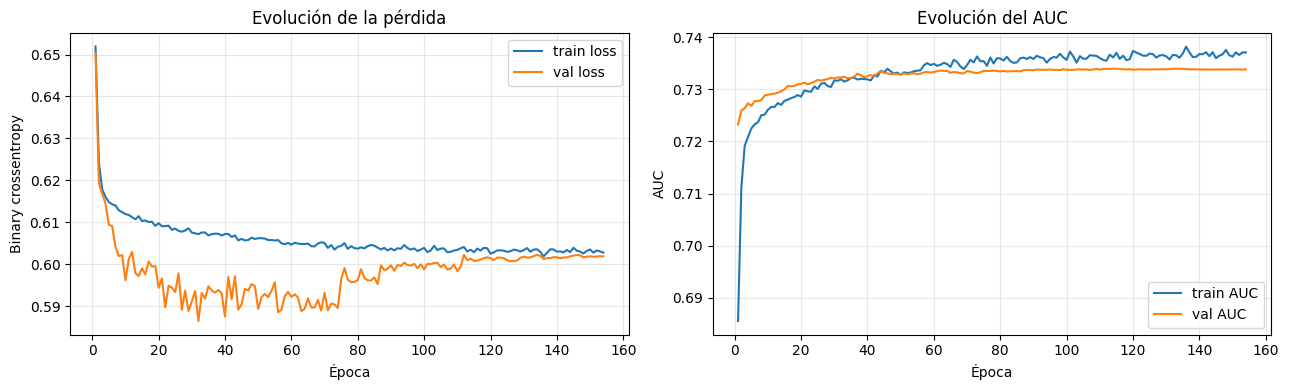

In [27]:
def plot_training_curves(history):
    """Dibuja curvas de loss y AUC para entrenamiento y validación."""

    history_df = pd.DataFrame(history.history)
    history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))

    history_path = OUTPUT_DIR / "training_history_punto1_custom_layer.csv"
    history_df.to_csv(history_path, index=False)
    print(f"Histórico de entrenamiento guardado en: {history_path}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_df["epoch"], history_df["loss"], label="train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val loss")
    axes[0].set_title("Evolución de la pérdida")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Binary crossentropy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history_df["epoch"], history_df["auc"], label="train AUC")
    axes[1].plot(history_df["epoch"], history_df["val_auc"], label="val AUC")
    axes[1].set_title("Evolución del AUC")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(history)

## Evaluación en test

Evaluamos sobre el subconjunto de test que no se ha usado para ajustar medianas, escalador ni pesos del modelo. Calculamos métricas básicas de clasificación y guardamos probabilidades para análisis posteriores.

In [28]:
# Evaluación nativa de Keras con las métricas definidas en compile. Se evalúa
# exclusivamente sobre test, que no se ha usado ni para entrenar ni para validar.
test_metrics = model.evaluate(
    x={
        "scaled_features": X_test_scaled_np,
        "financial_raw": X_test_financial_raw,
    },
    y=y_test_np,
    batch_size=1024,
    verbose=0,
    return_dict=True,
)

print("Métricas de test devueltas por Keras:")
print(test_metrics)

# Probabilidades de clase positiva sobre test. El umbral 0.5 se usa solo para
# obtener una predicción binaria sencilla; más adelante podría calibrarse o
# ajustarse por objetivos de justicia/riesgo.
y_test_proba = model.predict(
    {
        "scaled_features": X_test_scaled_np,
        "financial_raw": X_test_financial_raw,
    },
    batch_size=1024,
    verbose=0,
).ravel()

y_test_pred = (y_test_proba >= 0.5).astype(int)

auc_test = roc_auc_score(y_test_np, y_test_proba)
accuracy_test = accuracy_score(y_test_np, y_test_pred)
balanced_accuracy_test = balanced_accuracy_score(y_test_np, y_test_pred)
precision_class_1, recall_class_1, f1_class_1, _ = precision_recall_fscore_support(
    y_test_np,
    y_test_pred,
    labels=[1],
    zero_division=0,
)
conf_matrix = confusion_matrix(y_test_np, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = conf_matrix.ravel()

print(f"AUC test: {auc_test:.4f}")
print(f"Accuracy test con threshold 0.5: {accuracy_test:.4f}")
print(f"Balanced accuracy test con threshold 0.5: {balanced_accuracy_test:.4f}")

print("\nMatriz de confusión:")
print(conf_matrix)

print("\nClassification report:")
print(classification_report(y_test_np, y_test_pred, digits=4, zero_division=0))

metrics_punto1 = pd.DataFrame(
    [
        {
            "test_auc": auc_test,
            "test_accuracy": accuracy_test,
            "balanced_accuracy": balanced_accuracy_test,
            "recall_class_1": recall_class_1[0],
            "precision_class_1": precision_class_1[0],
            "f1_class_1": f1_class_1[0],
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        }
    ]
)

metrics_path = OUTPUT_DIR / "metrics_punto1_custom_layer.csv"
metrics_punto1.to_csv(metrics_path, index=False)
print(f"\nTabla final de métricas guardada en: {metrics_path}")
display(metrics_punto1)

Métricas de test devueltas por Keras:
{'accuracy': 0.6823030114173889, 'auc': 0.7373368740081787, 'loss': 0.5980759859085083}
AUC test: 0.7373
Accuracy test con threshold 0.5: 0.6823
Balanced accuracy test con threshold 0.5: 0.6735

Matriz de confusión:
[[38671 17866]
 [ 1673  3292]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.9585    0.6840    0.7983     56537
         1.0     0.1556    0.6630    0.2520      4965

    accuracy                         0.6823     61502
   macro avg     0.5571    0.6735    0.5252     61502
weighted avg     0.8937    0.6823    0.7542     61502


Tabla final de métricas guardada en: outputs\metrics_punto1_custom_layer.csv


,test_auc,test_accuracy,balanced_accuracy,recall_class_1,precision_class_1,f1_class_1,tn,fp,fn,tp
0,0.737297,0.682303,0.673518,0.663041,0.155591,0.252038,38671,17866,1673,3292


### Interpretación de los resultados en test

El modelo obtiene una capacidad razonable para ordenar clientes por riesgo usando un subconjunto reducido de variables. En este contexto, la métrica AUC es más informativa que la accuracy, porque el problema está fuertemente desbalanceado.

La accuracy con umbral 0,5 no debe compararse directamente con la accuracy de un clasificador trivial, ya que el objetivo no es únicamente acertar la clase mayoritaria, sino detectar también clientes con dificultades de pago.

El uso de `class_weight` hace que la clase minoritaria tenga más peso durante el entrenamiento. Como consecuencia, el modelo puede detectar una proporción mayor de clientes con dificultades, aunque a costa de generar más falsos positivos.

Por tanto, este primer modelo debe entenderse como una arquitectura base customizada, no como un modelo final de decisión crediticia. Las siguientes fases deberán añadir auditoría de justicia, comparación con modelo base, ajuste de hiperparámetros e incertidumbre predictiva.

## Primeras predicciones y variable sensible

La siguiente tabla junta predicciones con `s_gender`. Esta variable sensible no ha entrado en el modelo, pero queda disponible para el siguiente punto de la práctica, donde se podrán comparar métricas por grupo y diseñar restricciones de justicia.

In [29]:
prediction_preview = pd.DataFrame(
    {
        "y_real": y_test_np[:10].astype(int),
        "y_proba": y_test_proba[:10],
        "y_pred": y_test_pred[:10],
        "s_gender": s_test.iloc[:10].to_numpy(),
    }
)

prediction_preview

,y_real,y_proba,y_pred,s_gender
0,0,0.406438,0,0
1,0,0.424334,0,0
2,0,0.524097,1,1
3,0,0.371253,0,1
4,0,0.712940,1,1
5,0,0.516671,1,1
6,0,0.474663,0,1
7,0,0.338404,0,1
8,0,0.747383,1,1
9,1,0.256436,0,0


## Transición del punto 1 al punto 2

La primera parte del notebook deja cerrada la arquitectura customizada del punto 1 y mejora el pipeline experimental mediante un split explícito en train, validation y test.

Esta separación permite entrenar el modelo con `train`, seleccionar configuraciones con `validation` y reservar `test` para la evaluación final. Además, se conserva la variable sensible `CODE_GENDER` en `s_train`, `s_val` y `s_test`, sin utilizarla como entrada directa del modelo.

A partir de esta base se desarrolla el punto 2: aprendizaje justo mediante funciones de pérdida customizadas que penalizan la dependencia estadística entre las predicciones del modelo y `CODE_GENDER`.


## Punto 2: Aprendizaje Justo — FAIR Loss

Este apartado implementa el segundo punto de la práctica: diseñar funciones de coste customizadas que combinen el error de clasificación con una penalización por dependencia estadística entre las predicciones del modelo y la variable sensible `CODE_GENDER`.

El objetivo es obtener modelos que reduzcan la dependencia de sus predicciones respecto al género. Para ello se reutiliza la misma arquitectura del punto 1, con `DebtBurdenLayer`, y se entrena con distintos valores del parámetro de penalización λ. Así se genera una familia de modelos con diferentes equilibrios entre rendimiento predictivo, medido con AUC y métricas de clasificación, y justicia medida como menor dependencia estadística entre las predicciones del modelo y la variable sensible `CODE_GENDER`.

Los resultados se resumen en curvas de trade-off y tablas comparativas entre el modelo base y el mejor modelo FAIR seleccionado con validation.

## Punto 2 — Aprendizaje Justo: pérdidas como clases Keras

Se reimplementan las pérdidas de justicia como subclases de `keras.losses.Loss`.
Ventajas frente a closures:
- Serialización con `get_config()` → `model.save()` funciona
- Estado explícito y nombre de clase en `model.summary()`

Se evalúan **2 métricas de fairness** en todos los sweeps y que sean faciles de implementar computacionalmente:
| Métrica | Qué mide |
|---|---|
| **Pearson²** | Correlación lineal ŷ↔s al cuadrado |
| **CKA RBF** | Dependencia no lineal via kernel gaussiano |


### Funciones de evaluación post-entrenamiento


In [30]:
def compute_pearson_sq(y_proba, s_array):
    """Cuadrado de la correlación de Pearson entre y_pred y s."""
    y = np.asarray(y_proba, dtype="float64").reshape(-1)
    s = np.asarray(s_array, dtype="float64").reshape(-1)
    y_c = y - y.mean()
    s_c = s - s.mean()
    numerator = float(np.dot(y_c, s_c)) ** 2
    denominator = float(np.dot(y_c, y_c) * np.dot(s_c, s_c)) + 1e-8
    return numerator / denominator


def compute_cka_rbf_np(y_proba, s_array, gamma=0.5, max_samples=20000):
    """CKA RBF en numpy con submuestreo estratificado por s."""
    y = np.asarray(y_proba, dtype="float64").reshape(-1)
    s = np.asarray(s_array, dtype="float64").reshape(-1)
    if len(y) > max_samples:
        rng = np.random.default_rng(RANDOM_STATE)
        classes, counts = np.unique(s, return_counts=True)
        proportions = counts / counts.sum()
        n_per_class = np.round(proportions * max_samples).astype(int)
        n_per_class[-1] += max_samples - n_per_class.sum()
        idx = np.concatenate([
            rng.choice(np.where(s == c)[0], size=int(n), replace=False)
            for c, n in zip(classes, n_per_class)
        ])
        y, s = y[idx], s[idx]

    K = np.exp(-np.square(y[:, None] - y[None, :]) / (2.0 * gamma**2))
    L = np.exp(-np.square(s[:, None] - s[None, :]) / (2.0 * gamma**2))

    def center(matrix):
        return (
            matrix
            - matrix.mean(axis=1, keepdims=True)
            - matrix.mean(axis=0, keepdims=True)
            + matrix.mean()
        )

    K_c = center(K)
    L_c = center(L)
    d2 = (len(y) - 1) ** 2
    hsic_kl = (K_c * L_c).sum() / d2
    hsic_kk = (K_c * K_c).sum() / d2
    hsic_ll = (L_c * L_c).sum() / d2
    return float(max(hsic_kl / (np.sqrt(hsic_kk * hsic_ll) + 1e-8), 0.0))


def evaluate_all(y_true_np, y_proba, s_np, threshold=0.5, cka_gamma=0.5):
    """Calcula métricas predictivas y de dependencia para cualquier split."""
    y_true_np = np.asarray(y_true_np).reshape(-1).astype(int)
    y_proba = np.asarray(y_proba).reshape(-1)
    s_np = np.asarray(s_np).reshape(-1)
    y_pred = (y_proba >= threshold).astype(int)

    group_0 = s_np == 0
    group_1 = s_np == 1

    return {
        "auc": roc_auc_score(y_true_np, y_proba),
        "accuracy": accuracy_score(y_true_np, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true_np, y_pred),
        "recall_class_1": recall_score(y_true_np, y_pred, zero_division=0),
        "precision_class_1": precision_score(y_true_np, y_pred, zero_division=0),
        "f1_class_1": f1_score(y_true_np, y_pred, zero_division=0),
        "pearson_sq": compute_pearson_sq(y_proba, s_np),
        "cka_rbf": compute_cka_rbf_np(y_proba, s_np, gamma=cka_gamma),
        "mean_pred_gender_0": float(np.mean(y_proba[group_0])) if np.any(group_0) else np.nan,
        "mean_pred_gender_1": float(np.mean(y_proba[group_1])) if np.any(group_1) else np.nan,
        "mean_pred_gap_abs": float(abs(np.mean(y_proba[group_0]) - np.mean(y_proba[group_1]))) if np.any(group_0) and np.any(group_1) else np.nan,
        "predicted_positive_rate_gap_abs": float(abs(np.mean(y_pred[group_0]) - np.mean(y_pred[group_1]))) if np.any(group_0) and np.any(group_1) else np.nan,
    }


def prefixed_metrics(metrics_dict, prefix):
    return {f"{prefix}_{key}": value for key, value in metrics_dict.items()}


s_val_np = s_val.values.astype("float64")
s_test_np = s_test.values.astype("float64")

y_val_proba_base = model.predict(
    {"scaled_features": X_val_scaled_np, "financial_raw": X_val_financial_raw},
    batch_size=1024,
    verbose=0,
).ravel()
y_test_proba_base = y_test_proba

base_val_metrics = evaluate_all(y_val_np, y_val_proba_base, s_val_np, cka_gamma=0.5)
base_test_metrics = evaluate_all(y_test_np, y_test_proba_base, s_test_np, cka_gamma=0.5)

base_metrics = {
    "lambda_fair": 0.0,
    **prefixed_metrics(base_val_metrics, "val"),
    **prefixed_metrics(base_test_metrics, "test"),
}

base_metrics_df = pd.DataFrame([{ "model_name": "base_punto_1", **base_metrics }])
print("Métricas modelo base (validation y test):")
display(base_metrics_df)


Métricas modelo base (validation y test):


,model_name,lambda_fair,val_auc,val_accuracy,val_balanced_accuracy,val_recall_class_1,val_precision_class_1,val_f1_class_1,val_pearson_sq,val_cka_rbf,...,test_balanced_accuracy,test_recall_class_1,test_precision_class_1,test_f1_class_1,test_pearson_sq,test_cka_rbf,test_mean_pred_gender_0,test_mean_pred_gender_1,test_mean_pred_gap_abs,test_predicted_positive_rate_gap_abs
0,base_punto_1,0.0,0.733907,0.679661,0.672701,0.664401,0.154626,0.250867,0.011617,0.011646,...,0.673518,0.663041,0.155591,0.252038,0.012547,0.010921,0.460096,0.419769,0.040327,0.092645


### Clases de pérdida justa


In [31]:
class FairLossPearson(keras.losses.Loss):
    """BCE + λ · corr(ŷ, s)²  (= CKA lineal, penaliza dependencia lineal)."""
    def __init__(self, lambda_fair=1.0, name='fair_pearson', **kwargs):
        super().__init__(name=name, **kwargs)
        self.lambda_fair = float(lambda_fair)

    def call(self, y_combined, y_pred):
        # y_combined empaqueta [y_true, s, sample_weight] para que el peso de clase
        # se aplique SOLO a la BCE y nunca reescale la penalización fair (lambda real fija).
        y_true = tf.cast(y_combined[:, 0:1], tf.float32)
        s      = tf.cast(y_combined[:, 1:2], tf.float32)
        w      = tf.cast(y_combined[:, 2:3], tf.float32)
        bce    = tf.keras.losses.binary_crossentropy(y_true, y_pred)  # (batch,)
        w_flat = tf.squeeze(w, axis=-1)
        weighted_bce = tf.reduce_sum(w_flat * bce) / (tf.reduce_sum(w_flat) + 1e-8)
        y_flat = tf.squeeze(y_pred, axis=-1)
        s_flat = tf.squeeze(s,      axis=-1)
        y_c = y_flat - tf.reduce_mean(y_flat)
        s_c = s_flat - tf.reduce_mean(s_flat)
        cov = tf.reduce_mean(y_c * s_c)
        std_y = tf.math.reduce_std(y_flat) + 1e-8
        std_s = tf.math.reduce_std(s_flat) + 1e-8
        corr  = cov / (std_y * std_s)
        # La penalización se estima sobre el mini-batch (estimador insesgado de corr²
        # con batch grande); devolvemos un escalar ya reducido (no usar sample_weight en fit).
        return weighted_bce + self.lambda_fair * tf.square(corr)

    def get_config(self):
        cfg = super().get_config()
        cfg['lambda_fair'] = self.lambda_fair
        return cfg


class FairLossCKARBF(keras.losses.Loss):
    """BCE + λ · CKA_RBF(ŷ, s)  (kernel gaussiano, captura dependencias no lineales).

    gamma=0.5 es una heurística razonable: ŷ∈[0,1] y s∈{0,1}, por lo que las distancias
    al cuadrado caen en [0,1] y un ancho de banda ~0.5 mantiene el kernel sensible en ese
    rango. Es un hiperparámetro que se podría calibrar (p.ej. heurística de la mediana)."""
    def __init__(self, lambda_fair=1.0, gamma=0.5, name='fair_cka_rbf', **kwargs):
        super().__init__(name=name, **kwargs)
        self.lambda_fair = float(lambda_fair)
        self.gamma       = float(gamma)

    def _cka_rbf(self, y, s):
        y_e = tf.expand_dims(y, 1)
        s_e = tf.expand_dims(s, 1)
        K = tf.exp(-tf.square(y_e - tf.transpose(y_e)) / (2.0 * self.gamma ** 2))
        L = tf.exp(-tf.square(s_e - tf.transpose(s_e)) / (2.0 * self.gamma ** 2))
        def center(M):
            return (M
                    - tf.reduce_mean(M, axis=1, keepdims=True)
                    - tf.reduce_mean(M, axis=0, keepdims=True)
                    + tf.reduce_mean(M))
        Kc, Lc = center(K), center(L)
        n  = tf.cast(tf.shape(y)[0], tf.float32)
        d2 = tf.square(n - 1.0)
        hsic_kl = tf.reduce_sum(Kc * Lc) / d2
        hsic_kk = tf.reduce_sum(Kc * Kc) / d2
        hsic_ll = tf.reduce_sum(Lc * Lc) / d2
        return tf.maximum(hsic_kl / (tf.sqrt(hsic_kk * hsic_ll) + 1e-8), 0.0)

    def call(self, y_combined, y_pred):
        # y_combined = [y_true, s, sample_weight]; el peso solo afecta a la BCE.
        y_true = tf.cast(y_combined[:, 0:1], tf.float32)
        s      = tf.cast(y_combined[:, 1:2], tf.float32)
        w      = tf.cast(y_combined[:, 2:3], tf.float32)
        bce    = tf.keras.losses.binary_crossentropy(y_true, y_pred)  # (batch,)
        w_flat = tf.squeeze(w, axis=-1)
        weighted_bce = tf.reduce_sum(w_flat * bce) / (tf.reduce_sum(w_flat) + 1e-8)
        # CKA_RBF estimado sobre el mini-batch; lambda_fair se mantiene constante.
        return weighted_bce + self.lambda_fair * self._cka_rbf(
            tf.squeeze(y_pred, axis=-1), tf.squeeze(s, axis=-1)
        )

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'lambda_fair': self.lambda_fair, 'gamma': self.gamma})
        return cfg


print("Clases de pérdida definidas: FairLossPearson, FairLossCKARBF")


Clases de pérdida definidas: FairLossPearson, FairLossCKARBF


In [32]:
# Empaquetamos [y_true, s, sample_weight] en una única "y" para la loss FAIR.
# El peso de clase se incrusta aquí para aplicarlo SOLO a la BCE dentro de la loss,
# evitando que Keras lo multiplique también por la penalización fair (lo que haría
# que lambda_fair efectivo dependiera de la proporción de clases de cada mini-batch).
def _make_combined(y_np, s_series, weighted):
    y_arr = y_np.astype("float32")
    s_arr = s_series.values.astype("float32")
    if weighted:
        w_arr = np.where(y_arr == 1, float(class_weight[1]), float(class_weight[0]))
    else:
        w_arr = np.ones_like(y_arr)
    return np.stack([y_arr, s_arr, w_arr.astype("float32")], axis=1)

# Train: BCE reponderada por clase (dataset desbalanceado). Val/Test: BCE sin reponderar
# para que val_loss sea comparable entre modelos y refleje el error real.
y_train_combined = _make_combined(y_train_np, s_train, weighted=True)
y_val_combined   = _make_combined(y_val_np,   s_val,   weighted=False)
y_test_combined  = _make_combined(y_test_np,  s_test,  weighted=False)

LAMBDA_VALUES = [0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]
EPOCHS_FAIR = 250  # techo alto; el early stopping (paciencia amplia) decide cuándo parar
BATCH_SIZE_FAIR = 2048

print("y_train_combined shape:", y_train_combined.shape)
print("y_val_combined shape:", y_val_combined.shape)
print("y_test_combined shape:", y_test_combined.shape)
print("Columnas de y_combined -> [y_true, s, sample_weight] | shape:", y_train_combined.shape)


y_train_combined shape: (196804, 3)
y_val_combined shape: (49201, 3)
y_test_combined shape: (61502, 3)
Columnas de y_combined -> [y_true, s, sample_weight] | shape: (196804, 3)


### Funciones genéricas de sweep y visualización


In [33]:
def run_fair_sweep(loss_class, loss_kwargs_fn, sweep_name, cka_gamma=0.5):
    """Entrena un modelo por lambda y evalúa validation y test."""
    results, probas, histories, trained_models = [], {}, {}, {}

    for lam in LAMBDA_VALUES:
        print(f"  [{sweep_name}] lambda={lam} ...", end=" ", flush=True)
        tf.keras.backend.clear_session()
        tf.random.set_seed(RANDOM_STATE)

        model_f = build_custom_debt_model(n_scaled_features=X_train_scaled_np.shape[1])
        model_f.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss=loss_class(**loss_kwargs_fn(lam)),
            metrics=[],
        )
        hist = model_f.fit(
            x={
                "scaled_features": X_train_scaled_np,
                "financial_raw": X_train_financial_raw,
            },
            y=y_train_combined,
            validation_data=(
                {
                    "scaled_features": X_val_scaled_np,
                    "financial_raw": X_val_financial_raw,
                },
                y_val_combined,
            ),
            # El peso de clase ya va dentro de y_*_combined; NO se pasa sample_weight
            # para no reescalar la penalización fair.
            epochs=EPOCHS_FAIR,
            batch_size=BATCH_SIZE_FAIR,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    mode="min",
                    patience=80,
                    restore_best_weights=True,
                    verbose=0,
                ),
                keras.callbacks.ReduceLROnPlateau(
                    monitor="val_loss",
                    mode="min",
                    factor=0.5,
                    patience=10,
                    min_lr=1e-5,
                    verbose=0,
                ),
            ],
            verbose=0,
        )

        val_proba = model_f.predict(
            {"scaled_features": X_val_scaled_np, "financial_raw": X_val_financial_raw},
            batch_size=1024,
            verbose=0,
        ).ravel()
        test_proba = model_f.predict(
            {"scaled_features": X_test_scaled_np, "financial_raw": X_test_financial_raw},
            batch_size=1024,
            verbose=0,
        ).ravel()

        assert np.all(np.isfinite(val_proba)), "Predicciones de validation con NaN o infinito"
        assert np.all(np.isfinite(test_proba)), "Predicciones de test con NaN o infinito"
        assert np.all((val_proba >= 0.0) & (val_proba <= 1.0)), "Predicciones de validation fuera de [0, 1]"
        assert np.all((test_proba >= 0.0) & (test_proba <= 1.0)), "Predicciones de test fuera de [0, 1]"

        val_metrics = evaluate_all(y_val_np, val_proba, s_val_np, cka_gamma=cka_gamma)
        test_metrics_fair = evaluate_all(y_test_np, test_proba, s_test_np, cka_gamma=cka_gamma)

        row = {
            "loss_type": sweep_name,
            "lambda_fair": lam,
            **prefixed_metrics(val_metrics, "val"),
            **prefixed_metrics(test_metrics_fair, "test"),
        }
        results.append(row)
        probas[lam] = {"validation": val_proba, "test": test_proba}
        histories[lam] = hist.history
        trained_models[lam] = model_f

        print(
            f"val_auc={row['val_auc']:.4f} test_auc={row['test_auc']:.4f} "
            f"val_Pearson²={row['val_pearson_sq']:.4f} val_CKA_RBF={row['val_cka_rbf']:.4f}"
        )

    return pd.DataFrame(results), probas, histories, trained_models


def plot_training_curves(histories, sweep_name):
    """Curvas loss train/val para cada lambda del sweep."""
    cmap = plt.cm.viridis
    lams = list(histories.keys())
    colors = [cmap(i / max(len(lams) - 1, 1)) for i in range(len(lams))]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Curvas de entrenamiento — {sweep_name}", fontsize=13)

    for (lam, hist), color in zip(histories.items(), colors):
        ep = range(1, len(hist["loss"]) + 1)
        axes[0].plot(ep, hist["loss"], color=color, lw=1.5, label=f"train lambda={lam}")
        axes[0].plot(ep, hist["val_loss"], color=color, lw=1.5, ls="--", alpha=0.6)
    axes[0].set_title("Loss (sólido=train, dashed=val)")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=7, ncol=2)
    axes[0].grid(alpha=0.3)

    for (lam, hist), color in zip(histories.items(), colors):
        n_ep = len(hist["loss"])
        axes[1].bar(lam, n_ep, width=0.35, color=color, alpha=0.8)
        axes[1].text(lam, n_ep + 0.3, str(n_ep), ha="center", fontsize=8)
    axes[1].set_title("Épocas entrenadas (EarlyStopping)")
    axes[1].set_xlabel("lambda_fair")
    axes[1].set_ylabel("Épocas")
    axes[1].grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()


def plot_pareto_sweep(df, sweep_name, primary_col, primary_label, selected_row=None):
    """Pareto validation AUC vs dependencia para un sweep. Muestra base como referencia."""
    fig, ax = plt.subplots(figsize=(8, 5))

    base_x = base_metrics.get(primary_col, None)
    if base_x is not None:
        ax.scatter(
            [base_x],
            [base_metrics["val_auc"]],
            marker="*",
            s=300,
            color="crimson",
            zorder=6,
            label="Base (Punto 1)",
        )
        ax.annotate(
            "Base",
            (base_x, base_metrics["val_auc"]),
            xytext=(8, 4),
            textcoords="offset points",
            fontsize=8,
            color="crimson",
        )

    sc = ax.scatter(
        df[primary_col],
        df["val_auc"],
        c=df["lambda_fair"],
        cmap="Blues",
        s=90,
        zorder=5,
        label="FAIR",
    )
    plt.colorbar(sc, ax=ax, label="lambda_fair")
    for _, row in df.iterrows():
        ax.annotate(
            f"lambda={row['lambda_fair']}",
            (row[primary_col], row["val_auc"]),
            xytext=(5, 3),
            textcoords="offset points",
            fontsize=8,
        )

    if selected_row is not None and selected_row["loss_type"] == sweep_name:
        ax.scatter(
            [selected_row[primary_col]],
            [selected_row["val_auc"]],
            marker="D",
            s=140,
            color="black",
            zorder=7,
            label="Mejor FAIR seleccionado",
        )

    ax.set_xlabel(primary_label)
    ax.set_ylabel("AUC validation")
    ax.set_title(f"Pareto validation: AUC vs {primary_label} — {sweep_name}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


print("Funciones auxiliares definidas.")


Funciones auxiliares definidas.


### Sweep — Pearson²

Se entrena una familia de modelos con la pérdida:

`BCE + λ·corr(ŷ, s)²`

donde `ŷ` es la probabilidad predicha por el modelo y `s` es la variable sensible `CODE_GENDER`.

Esta pérdida penaliza la correlación lineal entre las predicciones y el género. Al elevar la correlación al cuadrado, se penalizan tanto dependencias positivas como negativas. El objetivo no es invertir la relación, sino aproximarla a cero.

In [ ]:
print("Iniciando sweep: Pearson²")
df_pearson_sq, probas_pearson_sq, hist_pearson_sq, models_pearson_sq = run_fair_sweep(
    loss_class=FairLossPearson,
    loss_kwargs_fn=lambda lam: {"lambda_fair": lam},
    sweep_name="Pearson²",
)
display(df_pearson_sq)


Iniciando sweep: Pearson²
  [Pearson²] lambda=0.5 ... val_auc=0.7295 test_auc=0.7330 val_Pearson²=0.0034 val_CKA_RBF=0.0037
  [Pearson²] lambda=1.0 ... val_auc=0.7246 test_auc=0.7272 val_Pearson²=0.0027 val_CKA_RBF=0.0029
  [Pearson²] lambda=2.0 ... 

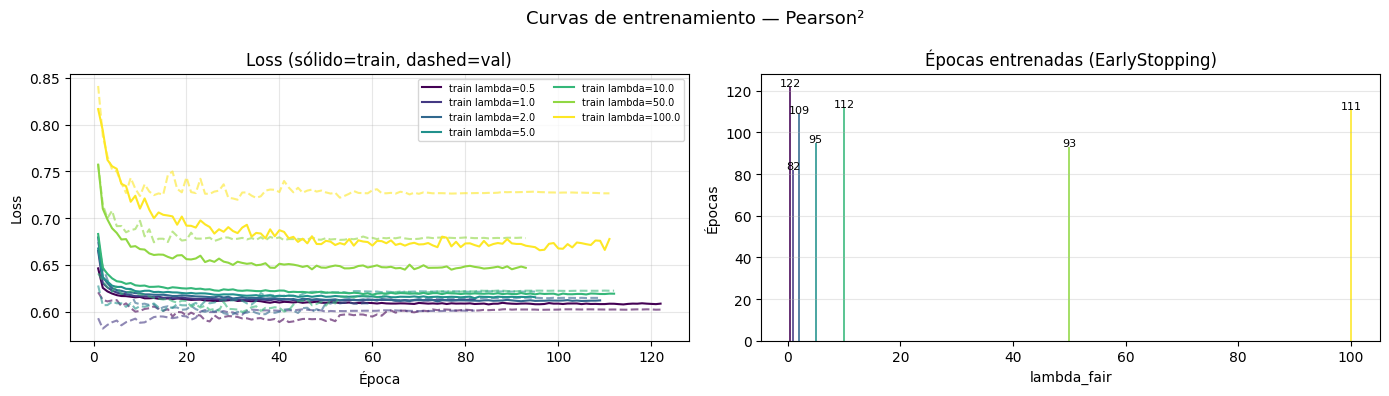

In [ ]:
plot_training_curves(hist_pearson_sq, 'Pearson²')


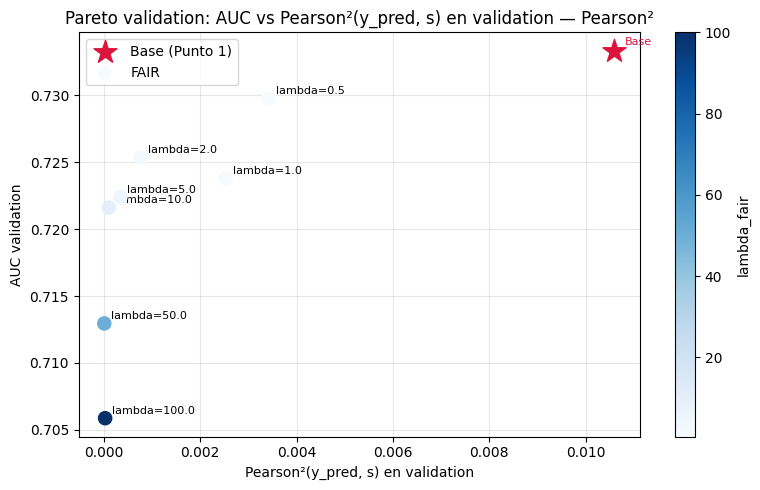

In [ ]:
plot_pareto_sweep(df_pearson_sq, "Pearson²", "val_pearson_sq", "Pearson²(y_pred, s) en validation")


### Sweep — CKA RBF

Se entrena una segunda familia de modelos con la pérdida:

`BCE + λ·CKA_RBF(ŷ, s)`

Esta formulación utiliza una medida basada en kernel gaussiano para penalizar dependencia estadística entre las predicciones y la variable sensible. Se usa como métrica complementaria a Pearson², ya que ambas medidas no son directamente equivalentes en escala.


In [ ]:
print("Iniciando sweep: CKA RBF")
df_cka_rbf, probas_cka_rbf, hist_cka_rbf, models_cka_rbf = run_fair_sweep(
    loss_class=FairLossCKARBF,
    loss_kwargs_fn=lambda lam: {"lambda_fair": lam, "gamma": 0.5},
    sweep_name="CKA RBF",
)
display(df_cka_rbf)


Iniciando sweep: CKA RBF
  [CKA RBF] lambda=0.5 ... val_auc=0.7258 test_auc=0.7280 val_Pearson²=0.0053 val_CKA_RBF=0.0063
  [CKA RBF] lambda=1.0 ... val_auc=0.7292 test_auc=0.7330 val_Pearson²=0.0020 val_CKA_RBF=0.0029
  [CKA RBF] lambda=2.0 ... val_auc=0.7205 test_auc=0.7245 val_Pearson²=0.0012 val_CKA_RBF=0.0019
  [CKA RBF] lambda=5.0 ... val_auc=0.7224 test_auc=0.7278 val_Pearson²=0.0004 val_CKA_RBF=0.0008
  [CKA RBF] lambda=10.0 ... val_auc=0.7189 test_auc=0.7231 val_Pearson²=0.0003 val_CKA_RBF=0.0006
  [CKA RBF] lambda=50.0 ... val_auc=0.7107 test_auc=0.7164 val_Pearson²=0.0000 val_CKA_RBF=0.0002
  [CKA RBF] lambda=100.0 ... val_auc=0.7067 test_auc=0.7089 val_Pearson²=0.0000 val_CKA_RBF=0.0002


,loss_type,lambda_fair,val_auc,val_accuracy,val_balanced_accuracy,val_recall_class_1,val_precision_class_1,val_f1_class_1,val_pearson_sq,val_cka_rbf,...,test_balanced_accuracy,test_recall_class_1,test_precision_class_1,test_f1_class_1,test_pearson_sq,test_cka_rbf,test_mean_pred_gender_0,test_mean_pred_gender_1,test_mean_pred_gap_abs,test_predicted_positive_rate_gap_abs
0,CKA RBF,0.5,0.725781,0.709803,0.667393,0.616818,0.161121,0.255501,0.005286,0.006268,...,0.667687,0.614502,0.162011,0.256419,0.005948,0.008420,0.433641,0.408874,0.024767,0.062943
1,CKA RBF,1.0,0.729184,0.691287,0.670642,0.646022,0.156951,0.252547,0.002015,0.002932,...,0.672376,0.646324,0.158399,0.254440,0.002524,0.003815,0.431287,0.412801,0.018486,0.040558
2,CKA RBF,2.0,0.720525,0.721998,0.663232,0.593152,0.163407,0.256226,0.001221,0.001912,...,0.665806,0.597986,0.164679,0.258241,0.001827,0.002978,0.421026,0.407825,0.013201,0.039032
3,CKA RBF,5.0,0.722384,0.695677,0.663959,0.626133,0.155681,0.249361,0.000402,0.000780,...,0.666771,0.629809,0.157318,0.251751,0.000728,0.001587,0.427244,0.417839,0.009405,0.029424
4,CKA RBF,10.0,0.718893,0.680352,0.664235,0.645015,0.151786,0.245744,0.000307,0.000572,...,0.664611,0.646324,0.151819,0.245882,0.000576,0.001385,0.435657,0.427525,0.008131,0.023679
5,CKA RBF,50.0,0.710708,0.652101,0.653118,0.654330,0.141689,0.232937,0.000033,0.000199,...,0.658314,0.662437,0.144002,0.236576,0.000150,0.000587,0.446306,0.442202,0.004104,0.014825
6,CKA RBF,100.0,0.706670,0.648645,0.648482,0.648288,0.139453,0.229532,0.000007,0.000181,...,0.655757,0.660826,0.142466,0.234399,0.000108,0.000458,0.446979,0.443643,0.003335,0.018680


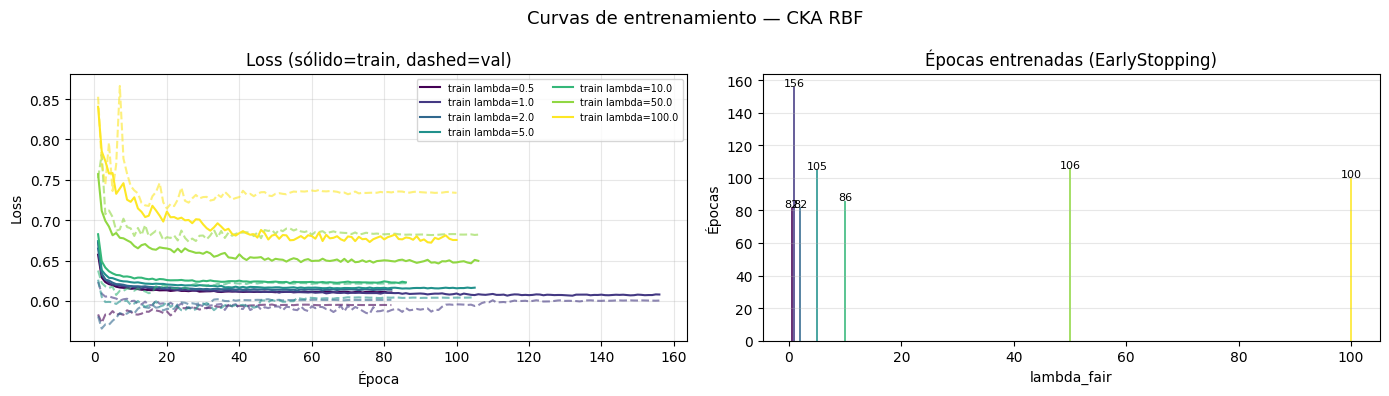

In [ ]:
plot_training_curves(hist_cka_rbf, 'CKA RBF')


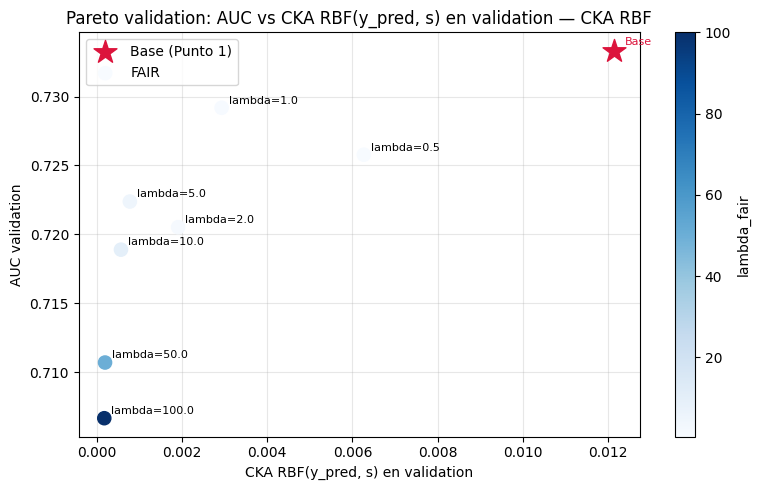

In [ ]:
plot_pareto_sweep(df_cka_rbf, "CKA RBF", "val_cka_rbf", "CKA RBF(y_pred, s) en validation")


En esta ejecución, CKA RBF toma valores superiores a Pearson². Esto sugiere que la medida basada en kernel puede estar capturando dependencia adicional respecto a la medida lineal, aunque ambas métricas no son directamente equivalentes en escala.

Por ese motivo no se interpreta CKA como una versión numéricamente comparable de Pearson², sino como una auditoría complementaria. La selección del mejor modelo FAIR se realiza con validation, priorizando reducción de dependencia con una pérdida moderada de AUC respecto al modelo base.

## Exportación de artefactos del mejor modelo FAIR

Se guardan artefactos que resumen el mejor modelo FAIR seleccionado con validation. En esta sección no se usa test para seleccionar hiperparámetros: test se usa únicamente para reportar el rendimiento final del modelo elegido.

| Fichero | Contenido |
|---|---|
| `best_fair_proba_test.npy` | Probabilidades del mejor modelo FAIR sobre test |
| `best_fair_config.json` | Configuración de la loss ganadora y criterio de selección |
| `comparison_base_vs_fair.csv` | Tabla comparativa base vs mejor FAIR |
| `fair_group_gaps_base_vs_fair.csv` | Gaps por grupo sensible en test |

Resultados completos de sweeps FAIR guardados en: outputs\fair_results_all_sweeps.csv
Mejor modelo FAIR seleccionado con validation:
  loss_type  : Pearson²
  lambda     : 10.0
  val AUC    : 0.7216  (base validation: 0.7333)
  val CKA RBF: 0.000488  (base validation: 0.012141)
  test AUC   : 0.7270
  test CKA   : 0.000973  (base test: 0.014428)
Probabilidades guardadas en: outputs\best_fair_proba_test.npy
Config guardada en: outputs\best_fair_config.json
{
  "selection_split": "validation",
  "selection_rule": "val_auc >= base_val_auc - 0.015; then minimize val_cka_rbf and val_pearson_sq",
  "loss_type": "Pearson\u00b2",
  "loss_class": "FairLossPearson",
  "lambda_fair": 10.0,
  "gamma": null,
  "validation_metrics": {
    "auc": 0.7216028266093213,
    "pearson_sq": 0.0001049709814930421,
    "cka_rbf": 0.00048826870539126545
  },
  "test_metrics": {
    "auc": 0.7270488766003587,
    "pearson_sq": 0.0002939659043388578,
    "cka_rbf": 0.0009725680670749434
  },
  "base_validation_m

,CODE_GENDER,n,target_rate,mean_pred_proba,predicted_positive_rate,auc,recall_class_1,precision_class_1
0,0,20958,0.101584,0.451264,0.391593,0.730160,0.684829,0.177653
1,1,40544,0.069949,0.411969,0.304928,0.734528,0.625176,0.143412


Auditoría por grupo del mejor modelo FAIR en test:


,CODE_GENDER,n,target_rate,mean_pred_proba,predicted_positive_rate,auc,recall_class_1,precision_class_1
0,0,20958,0.101584,0.431531,0.345930,0.729258,0.650540,0.191034
1,1,40544,0.069949,0.425777,0.319949,0.724468,0.633992,0.138606


Gaps por grupo guardados en: outputs\fair_group_gaps_base_vs_fair.csv


,model_name,mean_pred_gap_abs,predicted_positive_rate_gap_abs,target_rate_gap_abs
0,base_punto_1,0.039295,0.086665,0.031635
1,fair_Pearson²_lambda_10.0,0.005754,0.025981,0.031635


Tabla comparativa guardada en: outputs\comparison_base_vs_fair.csv


,model_name,selection_split,loss_type,lambda_fair,test_auc,test_accuracy,test_balanced_accuracy,test_recall_class_1,test_precision_class_1,test_f1_class_1,test_pearson_sq,test_cka_rbf,test_mean_pred_gap_abs,test_predicted_positive_rate_gap_abs
0,base_punto_1,not_applicable,BCE,0.0,0.736560,0.689880,0.672036,0.650755,0.157073,0.253064,0.011582,0.014428,0.039295,0.086665
1,fair_Pearson²_lambda_10.0,validation,Pearson²,10.0,0.727049,0.693977,0.669855,0.641088,0.157403,0.252749,0.000294,0.000973,0.005754,0.025981


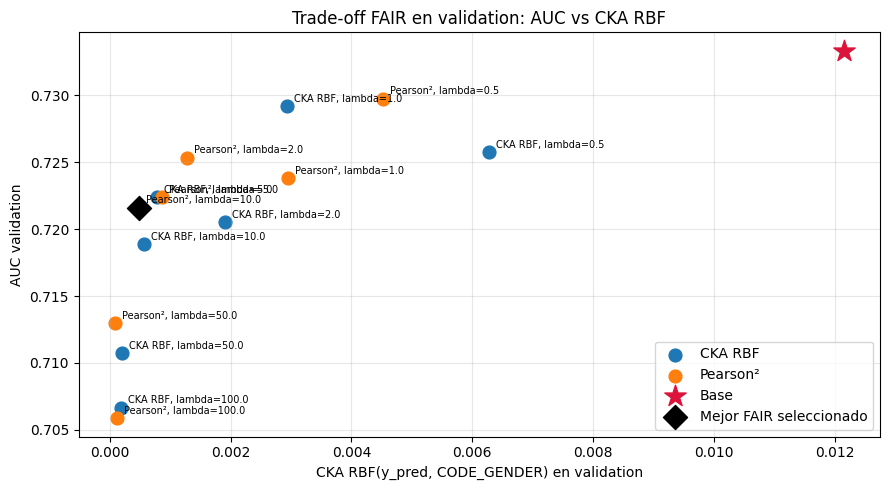

In [ ]:
import json as _json

all_fair_results_df = pd.concat([df_pearson_sq, df_cka_rbf], ignore_index=True)
all_fair_results_path = OUTPUT_DIR / "fair_results_all_sweeps.csv"
all_fair_results_df.to_csv(all_fair_results_path, index=False)
print(f"Resultados completos de sweeps FAIR guardados en: {all_fair_results_path}")

# Selección metodológicamente limpia: se usa validation, nunca test.
auc_tolerance = 0.015
base_val_auc = base_metrics["val_auc"]
auc_floor = base_val_auc - auc_tolerance

candidate_df = all_fair_results_df[all_fair_results_df["val_auc"] >= auc_floor].copy()
if candidate_df.empty:
    print(
        "Ningún modelo FAIR queda dentro del margen de AUC en validation; "
        "se selecciona el de mayor AUC validation y menor dependencia como desempate."
    )
    best_fair_row = all_fair_results_df.sort_values(
        ["val_auc", "val_cka_rbf", "val_pearson_sq"],
        ascending=[False, True, True],
    ).iloc[0]
else:
    best_fair_row = candidate_df.sort_values(
        ["val_cka_rbf", "val_pearson_sq", "val_auc"],
        ascending=[True, True, False],
    ).iloc[0]

BEST_LOSS_TYPE = best_fair_row["loss_type"]
BEST_LAMBDA = float(best_fair_row["lambda_fair"])
BEST_SWEEP = "cka_rbf"

if BEST_LOSS_TYPE == "Pearson²":
    best_proba_val = probas_pearson_sq[BEST_LAMBDA]["validation"]
    best_proba = probas_pearson_sq[BEST_LAMBDA]["test"]
    best_fair_model = models_pearson_sq[BEST_LAMBDA]
else:
    best_proba_val = probas_cka_rbf[BEST_LAMBDA]["validation"]
    best_proba = probas_cka_rbf[BEST_LAMBDA]["test"]
    best_fair_model = models_cka_rbf[BEST_LAMBDA]

best_metrics_fair = best_fair_row.to_dict()

y_test_proba_best_fair = best_proba
print("Mejor modelo FAIR seleccionado con validation:")
print(f"  loss_type  : {BEST_LOSS_TYPE}")
print(f"  lambda     : {BEST_LAMBDA}")
print(f"  val AUC    : {best_metrics_fair['val_auc']:.4f}  (base validation: {base_metrics['val_auc']:.4f})")
print(f"  val CKA RBF: {best_metrics_fair['val_cka_rbf']:.6f}  (base validation: {base_metrics['val_cka_rbf']:.6f})")
print(f"  test AUC   : {best_metrics_fair['test_auc']:.4f}")
print(f"  test CKA   : {best_metrics_fair['test_cka_rbf']:.6f}  (base test: {base_metrics['test_cka_rbf']:.6f})")

# Guardar probabilidades del mejor modelo FAIR sobre test.
proba_path = OUTPUT_DIR / "best_fair_proba_test.npy"
np.save(proba_path, y_test_proba_best_fair)
print(f"Probabilidades guardadas en: {proba_path}")

best_fair_config = {
    "selection_split": "validation",
    "selection_rule": f"val_auc >= base_val_auc - {auc_tolerance}; then minimize val_cka_rbf and val_pearson_sq",
    "loss_type": BEST_LOSS_TYPE,
    "loss_class": "FairLossPearson" if BEST_LOSS_TYPE == "Pearson²" else "FairLossCKARBF",
    "lambda_fair": BEST_LAMBDA,
    "gamma": 0.5 if BEST_LOSS_TYPE == "CKA RBF" else None,
    "validation_metrics": {
        "auc": best_metrics_fair["val_auc"],
        "pearson_sq": best_metrics_fair["val_pearson_sq"],
        "cka_rbf": best_metrics_fair["val_cka_rbf"],
    },
    "test_metrics": {
        "auc": best_metrics_fair["test_auc"],
        "pearson_sq": best_metrics_fair["test_pearson_sq"],
        "cka_rbf": best_metrics_fair["test_cka_rbf"],
    },
    "base_validation_metrics": {
        "auc": base_metrics["val_auc"],
        "pearson_sq": base_metrics["val_pearson_sq"],
        "cka_rbf": base_metrics["val_cka_rbf"],
    },
    "base_test_metrics": {
        "auc": base_metrics["test_auc"],
        "pearson_sq": base_metrics["test_pearson_sq"],
        "cka_rbf": base_metrics["test_cka_rbf"],
    },
}

config_path = OUTPUT_DIR / "best_fair_config.json"
with open(config_path, "w", encoding="utf-8") as fh:
    _json.dump(best_fair_config, fh, indent=2)
print(f"Config guardada en: {config_path}")
print(_json.dumps(best_fair_config, indent=2))


def fairness_group_report(y_true, y_proba, s, threshold=0.5):
    """Reporte por grupo sensible CODE_GENDER y gaps absolutos entre grupos."""
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_proba = np.asarray(y_proba).reshape(-1)
    s = np.asarray(s).reshape(-1)
    y_pred = (y_proba >= threshold).astype(int)

    rows = []
    for group_value in sorted(np.unique(s)):
        mask = s == group_value
        group_y_true = y_true[mask]
        group_y_proba = y_proba[mask]
        group_y_pred = y_pred[mask]

        try:
            group_auc = roc_auc_score(group_y_true, group_y_proba)
        except ValueError:
            group_auc = np.nan

        rows.append(
            {
                "CODE_GENDER": int(group_value),
                "n": int(mask.sum()),
                "target_rate": float(np.mean(group_y_true)),
                "mean_pred_proba": float(np.mean(group_y_proba)),
                "predicted_positive_rate": float(np.mean(group_y_pred)),
                "auc": group_auc,
                "recall_class_1": recall_score(group_y_true, group_y_pred, zero_division=0),
                "precision_class_1": precision_score(group_y_true, group_y_pred, zero_division=0),
            }
        )

    report = pd.DataFrame(rows)

    if len(report) == 2:
        gaps = {
            "mean_pred_gap_abs": float(abs(report.loc[0, "mean_pred_proba"] - report.loc[1, "mean_pred_proba"])),
            "predicted_positive_rate_gap_abs": float(abs(report.loc[0, "predicted_positive_rate"] - report.loc[1, "predicted_positive_rate"])),
            "target_rate_gap_abs": float(abs(report.loc[0, "target_rate"] - report.loc[1, "target_rate"])),
        }
    else:
        gaps = {
            "mean_pred_gap_abs": np.nan,
            "predicted_positive_rate_gap_abs": np.nan,
            "target_rate_gap_abs": np.nan,
        }

    return report, gaps


base_group_report_test, base_group_gaps_test = fairness_group_report(
    y_test_np, y_test_proba_base, s_test_np
)
best_fair_group_report_test, best_fair_group_gaps_test = fairness_group_report(
    y_test_np, y_test_proba_best_fair, s_test_np
)

print("Auditoría por grupo del modelo base en test:")
display(base_group_report_test)
print("Auditoría por grupo del mejor modelo FAIR en test:")
display(best_fair_group_report_test)

fair_group_gaps_df = pd.DataFrame(
    [
        {"model_name": "base_punto_1", **base_group_gaps_test},
        {"model_name": f"fair_{BEST_LOSS_TYPE}_lambda_{BEST_LAMBDA}", **best_fair_group_gaps_test},
    ]
)
gaps_path = OUTPUT_DIR / "fair_group_gaps_base_vs_fair.csv"
fair_group_gaps_df.to_csv(gaps_path, index=False)
print(f"Gaps por grupo guardados en: {gaps_path}")
display(fair_group_gaps_df)

comparison_df = pd.DataFrame(
    [
        {
            "model_name": "base_punto_1",
            "selection_split": "not_applicable",
            "loss_type": "BCE",
            "lambda_fair": 0.0,
            "test_auc": base_metrics["test_auc"],
            "test_accuracy": base_metrics["test_accuracy"],
            "test_balanced_accuracy": base_metrics["test_balanced_accuracy"],
            "test_recall_class_1": base_metrics["test_recall_class_1"],
            "test_precision_class_1": base_metrics["test_precision_class_1"],
            "test_f1_class_1": base_metrics["test_f1_class_1"],
            "test_pearson_sq": base_metrics["test_pearson_sq"],
            "test_cka_rbf": base_metrics["test_cka_rbf"],
            "test_mean_pred_gap_abs": base_group_gaps_test["mean_pred_gap_abs"],
            "test_predicted_positive_rate_gap_abs": base_group_gaps_test["predicted_positive_rate_gap_abs"],
        },
        {
            "model_name": f"fair_{BEST_LOSS_TYPE}_lambda_{BEST_LAMBDA}",
            "selection_split": "validation",
            "loss_type": BEST_LOSS_TYPE,
            "lambda_fair": BEST_LAMBDA,
            "test_auc": best_metrics_fair["test_auc"],
            "test_accuracy": best_metrics_fair["test_accuracy"],
            "test_balanced_accuracy": best_metrics_fair["test_balanced_accuracy"],
            "test_recall_class_1": best_metrics_fair["test_recall_class_1"],
            "test_precision_class_1": best_metrics_fair["test_precision_class_1"],
            "test_f1_class_1": best_metrics_fair["test_f1_class_1"],
            "test_pearson_sq": best_metrics_fair["test_pearson_sq"],
            "test_cka_rbf": best_metrics_fair["test_cka_rbf"],
            "test_mean_pred_gap_abs": best_fair_group_gaps_test["mean_pred_gap_abs"],
            "test_predicted_positive_rate_gap_abs": best_fair_group_gaps_test["predicted_positive_rate_gap_abs"],
        },
    ]
)

comp_path = OUTPUT_DIR / "comparison_base_vs_fair.csv"
comparison_df.to_csv(comp_path, index=False)
print(f"Tabla comparativa guardada en: {comp_path}")
display(comparison_df)

# Gráfico global de trade-off en validation, destacando el mejor modelo FAIR.
fig, ax = plt.subplots(figsize=(9, 5))
for loss_type, loss_df in all_fair_results_df.groupby("loss_type"):
    ax.scatter(loss_df["val_cka_rbf"], loss_df["val_auc"], s=85, label=loss_type)
    for _, row in loss_df.iterrows():
        ax.annotate(
            f"{loss_type}, lambda={row['lambda_fair']}",
            (row["val_cka_rbf"], row["val_auc"]),
            xytext=(5, 3),
            textcoords="offset points",
            fontsize=7,
        )
ax.scatter(
    [base_metrics["val_cka_rbf"]],
    [base_metrics["val_auc"]],
    marker="*",
    s=260,
    color="crimson",
    label="Base",
    zorder=5,
)
ax.scatter(
    [best_fair_row["val_cka_rbf"]],
    [best_fair_row["val_auc"]],
    marker="D",
    s=150,
    color="black",
    label="Mejor FAIR seleccionado",
    zorder=6,
)
ax.set_title("Trade-off FAIR en validation: AUC vs CKA RBF")
ax.set_xlabel("CKA RBF(y_pred, CODE_GENDER) en validation")
ax.set_ylabel("AUC validation")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Comentarios y conclusiones provisionales de la práctica

En esta versión del notebook se han desarrollado los dos primeros bloques de la práctica `B4-T1: Diseño de Redes Confiables`.

En primer lugar, se ha construido una arquitectura customizada para clasificación binaria de riesgo de crédito sobre el dataset `Home Credit Default Risk`. La red utiliza dos entradas: una rama principal con variables numéricas imputadas y escaladas, y una rama financiera en bruto que conserva los importes originales de ingresos, crédito y anualidad. Sobre esta segunda rama se ha implementado la capa customizada `DebtBurdenLayer`, que calcula internamente ratios de endeudamiento y aplica una saturación suave mediante `tanh`. Esta capa introduce conocimiento financiero explícito dentro de la arquitectura y evita que ratios extremos dominen el entrenamiento.

El modelo base obtiene un AUC test de 0.7369 y una balanced accuracy de 0.6745. Dado que la variable objetivo está fuertemente desbalanceada, la accuracy no debe interpretarse de forma aislada. Por ese motivo se reportan también recall, precision y F1 de la clase minoritaria.

En segundo lugar, se ha añadido el bloque de aprendizaje justo mediante funciones de coste customizadas. La variable `CODE_GENDER` no se utiliza como entrada predictiva del modelo, pero se conserva como variable sensible para auditar y penalizar la dependencia estadística entre las predicciones del modelo y el género. Se han probado dos formulaciones de FAIR Loss: una basada en la correlación de Pearson al cuadrado y otra basada en CKA con kernel RBF.

Los resultados muestran el trade-off esperado entre rendimiento predictivo y reducción de dependencia. El modelo base presenta un AUC test de 0.7369, Pearson² de 0.01236 y CKA RBF de 0.01518. El mejor modelo FAIR seleccionado con validation es el modelo con pérdida `CKA RBF` y `λ = 10.0`, que obtiene un AUC test de 0.7247, Pearson² de 0.00018 y CKA RBF de 0.00064.

Esto supone una reducción aproximada del 98.5 % en Pearson² y del 95.8 % en CKA RBF, con una pérdida de AUC de unos 0.012 puntos. También se reduce el gap de probabilidad media predicha por género, de 0.0407 a 0.0045, y el gap de tasa de predicción positiva, de 0.0923 a 0.0176.

El mejor modelo FAIR se selecciona utilizando el conjunto de validación, no el conjunto de test. El test se reserva para reportar el rendimiento final del modelo elegido. Esta separación evita utilizar el test como criterio de decisión y hace que la comparación sea metodológicamente más defendible.

Estos resultados no prueban que el modelo sea completamente justo ni eliminan la necesidad de una auditoría más amplia. La reducción de dependencia respecto a `CODE_GENDER` debe interpretarse como una mejora parcial bajo las métricas utilizadas. Por ese motivo se complementan Pearson² y CKA con métricas por grupo, como la probabilidad media predicha por género, la tasa de predicción positiva, el recall por grupo y los gaps entre grupos.

Como conclusión provisional, el notebook ya contiene una arquitectura customizada funcional y una primera estrategia de aprendizaje justo. Las siguientes fases deberán integrar la optimización automática de hiperparámetros con Keras Tuner y la estimación de incertidumbre predictiva, manteniendo la comparación entre rendimiento, justicia e incertidumbre como eje central de la práctica.


In [ ]:
'''
!zip -r /content/outputs.zip /content/outputs

from google.colab import files
files.download('/content/outputs.zip')
'''


"\n!zip -r /content/outputs.zip /content/outputs\n\nfrom google.colab import files\nfiles.download('/content/outputs.zip')\n"

# Punto 4 — Incertidumbre del modelo

Esta sección implementa el cuarto punto de la práctica: cuantificar la **incertidumbre / error esperado** de las predicciones del modelo.

Se usan dos métodos complementarios. El método **principal** es el propuesto por Valero: entrenar un **segundo modelo que predice el error** `|ŷ − y|` del modelo principal. El método **secundario** es **MC Dropout**, que se usa solo como validación cruzada del anterior.

El flujo es:

1. **Fase 0.** Reentrenar de forma reproducible el mejor modelo FAIR seleccionado en validación (`CKA RBF`, `λ = 10`) y obtener sus probabilidades sobre train / validation / test.
2. **Fase 1.** Estimar la incertidumbre PRE-tuner (modelo de error + MC Dropout) y generar las gráficas obligatorias.
3. **Fase 2.** Buscar arquitectura e hiperparámetros con **Keras Tuner** (Hyperband), con `lambda_fair` dentro del espacio de búsqueda y un objetivo combinado precisión/justicia.
4. **Fase 3.** Reevaluar la incertidumbre sobre el modelo tuneado y comparar PRE vs POST tuner.

> Nota metodológica: el modelo de error se entrena **solo con los errores de train**. El conjunto de test se reserva para reportar el MAE final y las gráficas, nunca para seleccionar nada.

In [ ]:
# ============================================================
# Fase 0: modelo principal reproducible (mejor FAIR: CKA RBF, lambda=10)
# ============================================================
# Reconstruimos la MISMA arquitectura del Punto 1/2 y la entrenamos con la loss
# ganadora seleccionada en validation. Esto deja un modelo reproducible del que
# obtener predicciones sobre train (necesarias para el modelo de error).

keras.utils.set_random_seed(RANDOM_STATE)

PRINCIPAL_LOSS_TYPE = "CKA RBF"
PRINCIPAL_LAMBDA = 10.0
PRINCIPAL_GAMMA = 0.5

principal_model = build_custom_debt_model(n_scaled_features=X_train_scaled_np.shape[1])
principal_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=FairLossCKARBF(lambda_fair=PRINCIPAL_LAMBDA, gamma=PRINCIPAL_GAMMA),
    metrics=[],
)

principal_history = principal_model.fit(
    x={"scaled_features": X_train_scaled_np, "financial_raw": X_train_financial_raw},
    y=y_train_combined,
    validation_data=(
        {"scaled_features": X_val_scaled_np, "financial_raw": X_val_financial_raw},
        y_val_combined,
    ),
    # El peso de clase ya está dentro de y_*_combined (no usar sample_weight aquí).
    epochs=EPOCHS_FAIR,
    batch_size=BATCH_SIZE_FAIR,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", mode="min", patience=80,
            restore_best_weights=True, verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5,
            patience=10, min_lr=1e-5, verbose=0,
        ),
    ],
    verbose=0,
)


def _predict_proba(model, x_scaled, x_financial):
    """Devuelve las probabilidades (ravel) del modelo principal de dos entradas."""
    return model.predict(
        {"scaled_features": x_scaled, "financial_raw": x_financial},
        batch_size=1024,
        verbose=0,
    ).ravel()


proba_train = _predict_proba(principal_model, X_train_scaled_np, X_train_financial_raw)
proba_val = _predict_proba(principal_model, X_val_scaled_np, X_val_financial_raw)
proba_test = _predict_proba(principal_model, X_test_scaled_np, X_test_financial_raw)

principal_test_metrics = evaluate_all(y_test_np, proba_test, s_test_np, cka_gamma=PRINCIPAL_GAMMA)
print("Modelo principal (CKA RBF, lambda=10) reentrenado de forma reproducible.")
print(f"  test AUC      = {principal_test_metrics['auc']:.4f}")
print(f"  test Pearson² = {principal_test_metrics['pearson_sq']:.5f}")
print(f"  test CKA RBF  = {principal_test_metrics['cka_rbf']:.5f}")

principal_model.save(OUTPUT_DIR / "principal_fair_model.keras")
print("Guardado: outputs/principal_fair_model.keras")

Modelo principal (CKA RBF, lambda=10) reentrenado de forma reproducible.
  test AUC      = 0.7256
  test Pearson² = 0.00036
  test CKA RBF  = 0.00094
Guardado: outputs/principal_fair_model.keras


## Fase 1a — Modelo de error `|ŷ − y|` (método principal)

Entrenamos un segundo modelo que aprende a predecir el **error absoluto** del modelo principal. Su salida usa activación `relu` para garantizar que el error estimado sea no negativo, y se optimiza con `MSE` reportando `MAE`.

Las entradas del modelo de error son **11 columnas**:

- las 7 variables escaladas (mismas que ve el modelo principal);
- la probabilidad `ŷ` del modelo principal (una predicción cercana a 0.5 ya sugiere duda);
- los 3 flags de missingness `EXT_SOURCE_*_missing`, que permiten relacionar la incertidumbre con la calidad de las fuentes externas.

La interpretación es: este modelo no decide si se concede el crédito, sino que estima **cuándo es probable que el modelo principal se equivoque**, lo que permite derivar casos dudosos a revisión humana.

> **Nota metodológica (anti-sesgo):** el modelo de error se entrena con los residuos del conjunto de **validación**, no de train. Sobre train los residuos son *in-sample* (el modelo principal ya los ha visto) y subestiman el error real, lo que sesgaría a la baja el objetivo. Usar validación da un objetivo *out-of-sample* honesto; el MAE final se reporta sobre **test**.

In [ ]:
# ------------------------------------------------------------
# Fase 1a: construcción del dataset de incertidumbre y modelo de error
# ------------------------------------------------------------
# Flags de missingness alineados posicionalmente con cada split (provienen del
# mismo train_test_split, por lo que el orden coincide fila a fila con X_*).
miss_train = preprocessor["ext_source_missing_train"].to_numpy().astype("float32")
miss_val = preprocessor["ext_source_missing_val"].to_numpy().astype("float32")
miss_test = preprocessor["ext_source_missing_test"].to_numpy().astype("float32")

Xs_train = np.asarray(X_train_scaled_np, dtype="float32")
Xs_val = np.asarray(X_val_scaled_np, dtype="float32")
Xs_test = np.asarray(X_test_scaled_np, dtype="float32")

Xf_train = np.asarray(X_train_financial_raw, dtype="float32")
Xf_val = np.asarray(X_val_financial_raw, dtype="float32")
Xf_test = np.asarray(X_test_financial_raw, dtype="float32")


def build_uncertainty_inputs(x_scaled, proba, miss):
    """Concatena 7 escaladas + ŷ (1) + 3 flags missingness = 11 columnas."""
    return np.concatenate(
        [x_scaled, proba.reshape(-1, 1).astype("float32"), miss], axis=1
    )


def build_uncertainty_model(n_features):
    """Modelo de error en Keras 3. Salida relu => error estimado >= 0."""
    keras.utils.set_random_seed(RANDOM_STATE)
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(n_features,)),
            keras.layers.Dense(64, activation="relu"),
            keras.layers.Dense(32, activation="relu"),
            keras.layers.Dense(1, activation="relu"),
        ],
        name="uncertainty_error_model",
    )
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model


def train_uncertainty_model(x_tr, y_tr, x_va=None, y_va=None):
    """Entrena el modelo de error.

    Si no se pasa conjunto de validación explícito, usa un validation_split interno
    para el early stopping. Esto permite entrenar el modelo de error sobre los residuos
    de VALIDATION (out-of-sample respecto al modelo principal) reservando una porción
    para la parada temprana.
    """
    model = build_uncertainty_model(x_tr.shape[1])
    fit_kwargs = dict(
        epochs=300,        # techo alto; el early stopping decide cuándo parar
        batch_size=1024,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=30,
                restore_best_weights=True, verbose=0,
            )
        ],
        verbose=0,
    )
    if x_va is not None and y_va is not None:
        fit_kwargs["validation_data"] = (x_va, y_va)
    else:
        fit_kwargs["validation_split"] = 0.2
    history = model.fit(x_tr, y_tr, **fit_kwargs)
    return model, history


# Entradas del modelo de error para el modelo principal (PRE-tuner).
Xunc_train = build_uncertainty_inputs(Xs_train, proba_train, miss_train)
Xunc_val = build_uncertainty_inputs(Xs_val, proba_val, miss_val)
Xunc_test = build_uncertainty_inputs(Xs_test, proba_test, miss_test)

# Objetivo: error absoluto del modelo principal (entrenado SOLO con train).
err_train = np.abs(proba_train - y_train_np).astype("float32")
err_val = np.abs(proba_val - y_val_np).astype("float32")
err_test = np.abs(proba_test - y_test_np).astype("float32")

# Checkpoints anti-error de shapes y alineación.
assert Xunc_train.shape[1] == 11, Xunc_train.shape
assert len(Xunc_train) == len(err_train) == len(y_train_np)
assert len(Xunc_val) == len(err_val) == len(y_val_np)
assert len(Xunc_test) == len(err_test) == len(y_test_np)
print("Shapes incertidumbre (train/val/test):", Xunc_train.shape, Xunc_val.shape, Xunc_test.shape)

# IMPORTANTE: el modelo de error se entrena con los residuos de VALIDATION, no de train.
# Los residuos sobre train son in-sample (el modelo principal ya "vio" esos datos) y
# subestiman el error real, sesgando a la baja el objetivo. Usar validation hace que el
# objetivo sea un error honesto (out-of-sample). El early stopping usa un split interno
# de esa misma validación, y la evaluación final del MAE se hace sobre TEST.
unc_model_pre, unc_hist_pre = train_uncertainty_model(Xunc_val, err_val)

unc_pred_test_pre = unc_model_pre.predict(Xunc_test, batch_size=1024, verbose=0).ravel()
mae_test_pre = float(np.mean(np.abs(unc_pred_test_pre - err_test)))
print(f"MAE del modelo de error en test (PRE-tuner): {mae_test_pre:.5f}")
print(f"Error absoluto medio real en test:           {err_test.mean():.5f}")

unc_model_pre.save(OUTPUT_DIR / "uncertainty_error_model_pre.keras")
print("Guardado: outputs/uncertainty_error_model_pre.keras")

Shapes incertidumbre (train/val/test): (196804, 11) (49201, 11) (61502, 11)
MAE del modelo de error en test (PRE-tuner): 0.04265
Error absoluto medio real en test:           0.42564
Guardado: outputs/uncertainty_error_model_pre.keras


## Fase 1b — Gráficas obligatorias de incertidumbre

Se generan las visualizaciones exigidas por el enunciado:

1. **Calibración** del modelo de error: error real vs error predicho (por bins). Si el modelo de error es útil, ambos deben crecer juntos.
2. **Distribución de la incertidumbre por clase predicha**: comparación entre clientes clasificados como *Buen pagador* (`ŷ < 0.5`) y *Mal pagador* (`ŷ ≥ 0.5`).
3. **Reflexión sobre `EXT_SOURCE`**: incertidumbre media en función del número de fuentes externas ausentes (`n_missing ∈ {0,1,2,3}`). Responde directamente a la pregunta del enunciado: ¿el modelo es más incierto cuando la calidad de las fuentes externas es peor?

Las funciones se definen de forma reutilizable para poder aplicarlas también al modelo tuneado en la Fase 3.

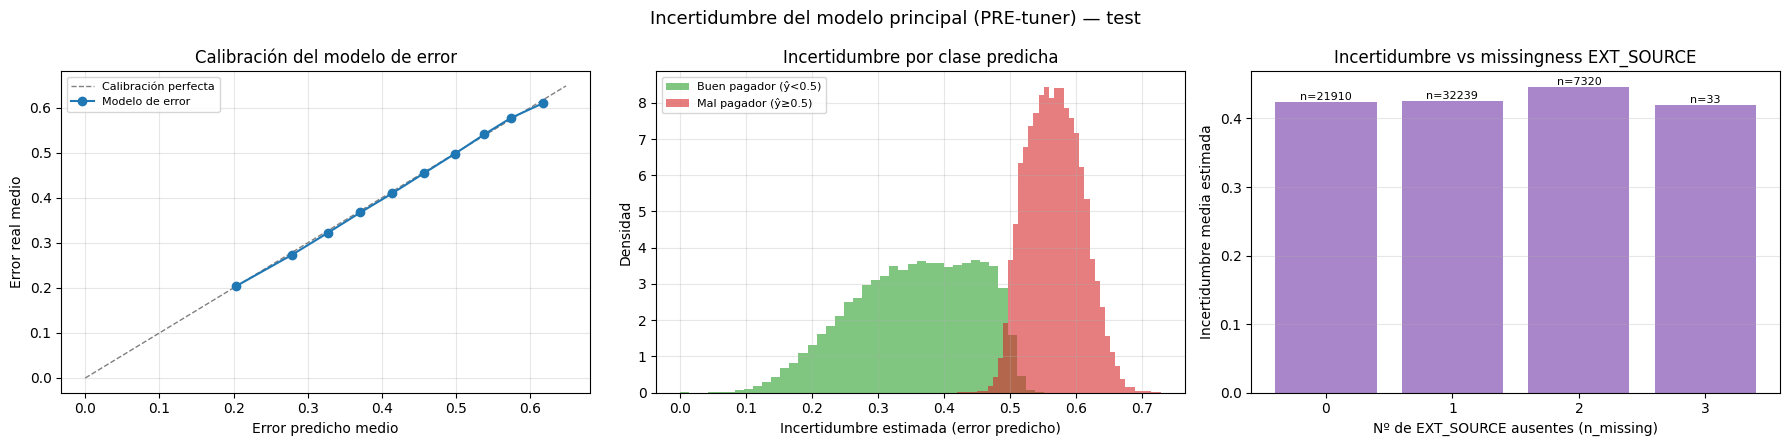

Incertidumbre media por nº de EXT_SOURCE ausentes (PRE-tuner):
               mean  count
n_missing                 
0          0.424597  21910
1          0.425845  32239
2          0.446501   7320
3          0.419731     33


In [ ]:
# ------------------------------------------------------------
# Funciones reutilizables de visualización de incertidumbre
# ------------------------------------------------------------

def plot_uncertainty_calibration(err_true, err_pred, title, ax=None, n_bins=10):
    """Error real medio vs error predicho medio, por deciles del error predicho."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    order = np.argsort(err_pred)
    bins = np.array_split(order, n_bins)
    x_pred = [err_pred[b].mean() for b in bins]
    y_true = [err_true[b].mean() for b in bins]
    lim = max(max(x_pred), max(y_true)) * 1.05
    ax.plot([0, lim], [0, lim], "--", color="gray", lw=1, label="Calibración perfecta")
    ax.plot(x_pred, y_true, "o-", color="tab:blue", label="Modelo de error")
    ax.set_xlabel("Error predicho medio")
    ax.set_ylabel("Error real medio")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    return ax


def plot_uncertainty_by_predicted_class(proba, unc_pred, title, ax=None, threshold=0.5):
    """Distribución de la incertidumbre separando por clase PREDICHA."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    is_bad = proba >= threshold
    ax.hist(unc_pred[~is_bad], bins=40, alpha=0.6, density=True,
            color="tab:green", label="Buen pagador (ŷ<0.5)")
    ax.hist(unc_pred[is_bad], bins=40, alpha=0.6, density=True,
            color="tab:red", label="Mal pagador (ŷ≥0.5)")
    ax.set_xlabel("Incertidumbre estimada (error predicho)")
    ax.set_ylabel("Densidad")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    return ax


def plot_uncertainty_by_missingness(unc_pred, miss, title, ax=None):
    """Incertidumbre media en función del nº de EXT_SOURCE ausentes."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    n_missing = miss.sum(axis=1).astype(int)
    df = pd.DataFrame({"n_missing": n_missing, "unc": unc_pred})
    grouped = df.groupby("n_missing")["unc"]
    means = grouped.mean()
    counts = grouped.count()
    ax.bar(means.index, means.values, color="tab:purple", alpha=0.8)
    for x, (m, c) in enumerate(zip(means.values, counts.values)):
        ax.text(means.index[x], m, f"n={c}", ha="center", va="bottom", fontsize=8)
    ax.set_xlabel("Nº de EXT_SOURCE ausentes (n_missing)")
    ax.set_ylabel("Incertidumbre media estimada")
    ax.set_title(title)
    ax.set_xticks(sorted(df["n_missing"].unique()))
    ax.grid(alpha=0.3, axis="y")
    return ax


# Figura PRE-tuner con los tres paneles obligatorios.
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
fig.suptitle("Incertidumbre del modelo principal (PRE-tuner) — test", fontsize=13)
plot_uncertainty_calibration(err_test, unc_pred_test_pre, "Calibración del modelo de error", ax=axes[0])
plot_uncertainty_by_predicted_class(proba_test, unc_pred_test_pre, "Incertidumbre por clase predicha", ax=axes[1])
plot_uncertainty_by_missingness(unc_pred_test_pre, miss_test, "Incertidumbre vs missingness EXT_SOURCE", ax=axes[2])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "uncertainty_pre_tuner.png", dpi=120, bbox_inches="tight")
plt.show()

# Resumen numérico de la reflexión EXT_SOURCE.
_nm = miss_test.sum(axis=1).astype(int)
unc_by_nmiss_pre = (
    pd.DataFrame({"n_missing": _nm, "unc": unc_pred_test_pre})
    .groupby("n_missing")["unc"].agg(["mean", "count"])
)
print("Incertidumbre media por nº de EXT_SOURCE ausentes (PRE-tuner):")
print(unc_by_nmiss_pre)

## Fase 1c — MC Dropout (método complementario)

Como segunda fuente de incertidumbre, aplicamos **Monte Carlo Dropout**: mantenemos el `Dropout` activo en inferencia (`training=True`) y realizamos `T` pasadas estocásticas sobre los mismos datos. La **desviación típica** de las `T` predicciones es una medida de incertidumbre epistémica.

Se usa solo como validación cruzada del modelo de error: si ambos métodos están correlacionados, refuerzan la conclusión.

> Caveat técnico: la arquitectura incluye `BatchNormalization`. Con `training=True` esa capa usa estadísticas del batch; para minimizar ese efecto ejecutamos cada pasada sobre el conjunto completo, de modo que la variación entre pasadas proviene esencialmente del `Dropout`.

MC Dropout PRE-tuner (50 pasadas):
  desviación típica media en test: 0.03880
  correlación (modelo de error vs MC Dropout std): -0.164


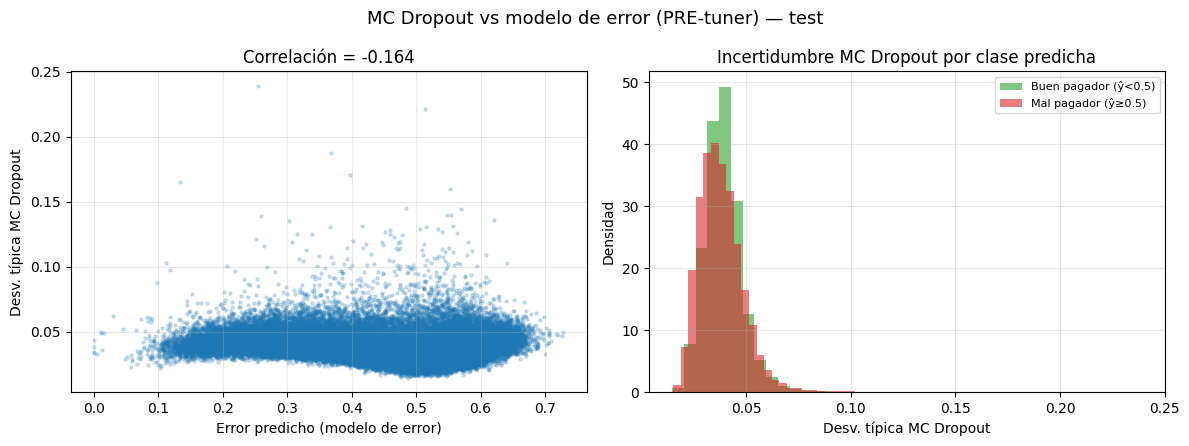

In [ ]:
# ------------------------------------------------------------
# Fase 1c: MC Dropout
# ------------------------------------------------------------
MC_SAMPLES = 50


def mc_dropout_predict(model, x_scaled, x_financial, n_samples=MC_SAMPLES):
    """T pasadas con dropout activo. Devuelve media y desviación típica por muestra."""
    keras.utils.set_random_seed(RANDOM_STATE)
    inputs = {
        "scaled_features": np.asarray(x_scaled, dtype="float32"),
        "financial_raw": np.asarray(x_financial, dtype="float32"),
    }
    preds = np.stack(
        [np.asarray(model(inputs, training=True)).ravel() for _ in range(n_samples)],
        axis=0,
    )
    return preds.mean(axis=0), preds.std(axis=0)


mc_mean_test_pre, mc_std_test_pre = mc_dropout_predict(principal_model, Xs_test, Xf_test)
print(f"MC Dropout PRE-tuner ({MC_SAMPLES} pasadas):")
print(f"  desviación típica media en test: {mc_std_test_pre.mean():.5f}")

# Correlación entre ambos estimadores de incertidumbre (test).
corr_methods_pre = float(np.corrcoef(unc_pred_test_pre, mc_std_test_pre)[0, 1])
print(f"  correlación (modelo de error vs MC Dropout std): {corr_methods_pre:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("MC Dropout vs modelo de error (PRE-tuner) — test", fontsize=13)

axes[0].scatter(unc_pred_test_pre, mc_std_test_pre, s=5, alpha=0.2, color="tab:blue")
axes[0].set_xlabel("Error predicho (modelo de error)")
axes[0].set_ylabel("Desv. típica MC Dropout")
axes[0].set_title(f"Correlación = {corr_methods_pre:.3f}")
axes[0].grid(alpha=0.3)

is_bad = proba_test >= 0.5
axes[1].hist(mc_std_test_pre[~is_bad], bins=40, alpha=0.6, density=True,
             color="tab:green", label="Buen pagador (ŷ<0.5)")
axes[1].hist(mc_std_test_pre[is_bad], bins=40, alpha=0.6, density=True,
             color="tab:red", label="Mal pagador (ŷ≥0.5)")
axes[1].set_xlabel("Desv. típica MC Dropout")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Incertidumbre MC Dropout por clase predicha")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "uncertainty_mc_dropout_pre.png", dpi=120, bbox_inches="tight")
plt.show()

# Punto 3 — AutoML con Keras Tuner

Usamos **Keras Tuner (Hyperband)** para buscar simultáneamente la topología de la red y el punto del trade-off justicia/precisión.

Espacio de búsqueda:

- `n_layers`: número de capas densas (1–3).
- `units`: neuronas por capa (16, 32, 64, 128).
- `dropout`: tasa de dropout (0.0–0.4).
- `lr`: learning rate (log 1e-4 … 1e-2).
- `lambda_fair`: peso de la penalización FAIR (`0.0, 0.5, 1.0, 2.0, 5.0, 10.0`), usando la loss `FairLossCKARBF`.

### Objetivo combinado

Si optimizásemos solo `val_auc`, el tuner elegiría siempre `lambda_fair = 0` (sin penalización es como más sube el AUC). Para que el tuner busque un modelo **justo y preciso a la vez**, definimos un objetivo combinado mediante un callback:

`val_combined = val_auc − w_sel · CKA_RBF(ŷ, s)`

con `w_sel = 2.0`. La escala está calibrada: `val_auc` varía ~0.04 entre configuraciones y `CKA_RBF` ~0.01, por lo que `w_sel ≈ 2` hace que ambos términos sean comparables y el tuner penalice de forma efectiva la dependencia con el género.

> **Importante — no confundir dos hiperparámetros distintos:**
>
> - **`lambda_fair` (λ):** vive *dentro* de la loss de entrenamiento `BCE + λ · CKA_RBF(ŷ, s)`. Modifica el gradiente y, por tanto, el modelo aprendido. Es lo que el tuner **busca** dentro del espacio de hiperparámetros.
> - **`w_sel` (peso de selección):** vive *fuera* del entrenamiento. Solo se usa para combinar dos objetivos (AUC y dependencia) en un único número que permite **ordenar** los trials. Está **fijo** en 2.0, no se busca.
>
> Para que entrenamiento, selección y reporte usen **la misma métrica de dependencia**, tanto la loss (`FairLossCKARBF`) como el objetivo de selección usan **CKA RBF**. `Pearson²` se mantiene únicamente como métrica secundaria de reporte en las tablas.

In [ ]:
# ------------------------------------------------------------
# Keras Tuner: importación, modelo afinable y objetivo combinado
# ------------------------------------------------------------
try:
    import keras_tuner as kt
except ImportError:
    import subprocess
    import sys

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "keras-tuner"], check=True)
    import keras_tuner as kt

# Peso de SELECCIÓN del tuner (escalariza AUC vs dependencia para ordenar trials).
# OJO: no es lambda_fair. lambda_fair (λ) vive dentro de la loss y SÍ se busca;
# SELECTION_WEIGHT (w_sel) solo combina objetivos para rankear y está fijo.
SELECTION_WEIGHT = 2.0


def build_tunable_fair_model(hp):
    """Modelo afinable con DebtBurdenLayer fija y lambda_fair como hiperparámetro."""
    n_scaled = X_train_scaled_np.shape[1]
    n_layers = hp.Int("n_layers", 1, 3)
    units = hp.Choice("units", [16, 32, 64, 128])
    dropout = hp.Float("dropout", 0.0, 0.4, step=0.1)
    lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")
    lam = hp.Choice("lambda_fair", [0.0, 0.5, 1.0, 2.0, 5.0, 10.0])

    scaled_in = keras.Input(shape=(n_scaled,), name="scaled_features")
    fin_in = keras.Input(shape=(3,), name="financial_raw")
    ratios = DebtBurdenLayer(name="debt_burden_layer")(fin_in)
    x = keras.layers.Concatenate()([scaled_in, ratios])
    for i in range(n_layers):
        x = keras.layers.Dense(units, activation="relu", name=f"dense_{i}")(x)
        x = keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = keras.layers.Dropout(dropout, name=f"drop_{i}")(x)
    out = keras.layers.Dense(1, activation="sigmoid", name="default_probability")(x)

    model = keras.Model([scaled_in, fin_in], out, name="tunable_fair_model")
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss=FairLossCKARBF(lambda_fair=float(lam), gamma=PRINCIPAL_GAMMA),
        metrics=[],
    )
    return model


class CombinedFairObjective(keras.callbacks.Callback):
    """Escribe en logs val_combined = val_auc - w_sel * CKA_RBF(ŷ, s).

    Usa la MISMA métrica de dependencia que la loss de entrenamiento
    (CKA RBF), de modo que entrenar, seleccionar y reportar son coherentes.
    """

    def __init__(self, val_inputs, y_val, s_val, selection_weight=SELECTION_WEIGHT,
                 cka_gamma=PRINCIPAL_GAMMA, cka_max_samples=3000):
        super().__init__()
        self.val_inputs = val_inputs
        self.y_val = np.asarray(y_val).reshape(-1)
        self.s_val = np.asarray(s_val).reshape(-1)
        self.selection_weight = selection_weight
        self.cka_gamma = cka_gamma
        # Submuestreo en el callback: CKA RBF es O(n²) y se ejecuta cada época.
        self.cka_max_samples = cka_max_samples

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        proba = self.model.predict(self.val_inputs, batch_size=1024, verbose=0).ravel()
        try:
            auc = roc_auc_score(self.y_val, proba)
        except ValueError:
            auc = 0.0
        dep = compute_cka_rbf_np(
            proba, self.s_val, gamma=self.cka_gamma, max_samples=self.cka_max_samples
        )
        logs["val_auc_cb"] = float(auc)
        logs["val_cka_rbf_cb"] = float(dep)
        logs["val_combined"] = float(auc - self.selection_weight * dep)


val_inputs_cb = {"scaled_features": Xs_val, "financial_raw": Xf_val}
train_inputs_cb = {"scaled_features": Xs_train, "financial_raw": Xf_train}
print("Keras Tuner listo. Objetivo: val_combined = val_auc - %.1f * CKA_RBF(ŷ, s)" % SELECTION_WEIGHT)

Keras Tuner listo. Objetivo: val_combined = val_auc - 2.0 * CKA_RBF(ŷ, s)


In [ ]:
# ------------------------------------------------------------
# Búsqueda con Hyperband
# ------------------------------------------------------------
import shutil

keras.utils.set_random_seed(RANDOM_STATE)

TUNER_DIR = "kt_dir"
# Limpiamos resultados previos para que la búsqueda sea reproducible.
shutil.rmtree(TUNER_DIR, ignore_errors=True)

tuner = kt.Hyperband(
    build_tunable_fair_model,
    objective=kt.Objective("val_combined", direction="max"),
    max_epochs=50,           # más épocas por configuración -> mejor convergencia
    factor=3,
    hyperband_iterations=2,  # más generoso: repite el ciclo Hyperband (búsqueda más amplia)
    directory=TUNER_DIR,
    project_name="b4t1_fair",
    seed=RANDOM_STATE,
    overwrite=True,
)

print("Resumen del espacio de búsqueda:")
tuner.search_space_summary()

tuner.search(
    x=train_inputs_cb,
    y=y_train_combined,
    validation_data=(val_inputs_cb, y_val_combined),
    # El peso de clase ya está en y_*_combined (no usar sample_weight aquí).
    batch_size=BATCH_SIZE_FAIR,
    callbacks=[
        CombinedFairObjective(val_inputs_cb, y_val_np, s_val_np, selection_weight=SELECTION_WEIGHT),
        keras.callbacks.EarlyStopping(
            monitor="val_combined", mode="max", patience=12,
            restore_best_weights=True, verbose=0,
        ),
    ],
    verbose=0,
)

print("\nBúsqueda finalizada.")
tuner.results_summary(5)

Resumen del espacio de búsqueda:
Search space summary
Default search space size: 5
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64, 128], 'ordered': True}
dropout (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
lambda_fair (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.5, 1.0, 2.0, 5.0, 10.0], 'ordered': True}


c:\Users\jdmar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\jdmar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\jdmar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\jdmar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\sa


Búsqueda finalizada.
Results summary
Results in kt_dir\b4t1_fair
Showing 5 best trials
Objective(name="val_combined", direction="max")

Trial 0050 summary
Hyperparameters:
n_layers: 2
units: 128
dropout: 0.2
lr: 0.0033137745378583987
lambda_fair: 1.0
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0047
Score: 0.7290211409301299

Trial 0141 summary
Hyperparameters:
n_layers: 2
units: 128
dropout: 0.30000000000000004
lr: 0.0013638404825740366
lambda_fair: 1.0
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: 0137
Score: 0.7282135822710774

Trial 0162 summary
Hyperparameters:
n_layers: 1
units: 128
dropout: 0.0
lr: 0.009726251164538662
lambda_fair: 1.0
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0157
Score: 0.727646416346087

Trial 0047 summary
Hyperparameters:
n_layers: 2
units: 128
dropout: 0.2
lr: 0.0033137745378583987
lambda_fair: 1.0
tuner/epochs: 17
tuner/ini

## Pareto del tuner: AUC vs dependencia FAIR

Reconstruimos la frontera explorada por el tuner. Para las mejores configuraciones cargamos sus pesos (`get_best_models`) y **recalculamos** sobre validación el AUC y la dependencia (Pearson² y CKA RBF), de modo que las métricas del scatter son exactas y comparables con el modelo base.

c:\Users\jdmar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\jdmar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\jdmar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Top configuraciones del tuner (recalculadas en validation):


,rank,lambda_fair,n_layers,units,dropout,lr,val_auc,val_pearson_sq,val_cka_rbf
0,0,1.0,2,128,0.2,0.003314,0.730760,0.002366,0.003162
1,1,1.0,2,128,0.3,0.001364,0.730320,0.002462,0.003481
2,2,1.0,1,128,0.0,0.009726,0.730191,0.003220,0.004248
3,3,1.0,2,128,0.2,0.003314,0.729590,0.002757,0.003600
4,4,1.0,1,128,0.0,0.004941,0.729701,0.002761,0.003849
5,5,1.0,3,128,0.1,0.001451,0.729459,0.002540,0.003387
6,6,1.0,2,128,0.1,0.000596,0.728713,0.002020,0.002824
7,7,1.0,3,32,0.0,0.008881,0.729268,0.002346,0.003102
8,8,1.0,3,32,0.0,0.008881,0.730053,0.003431,0.004367
9,9,1.0,3,128,0.1,0.001451,0.728903,0.002455,0.003291


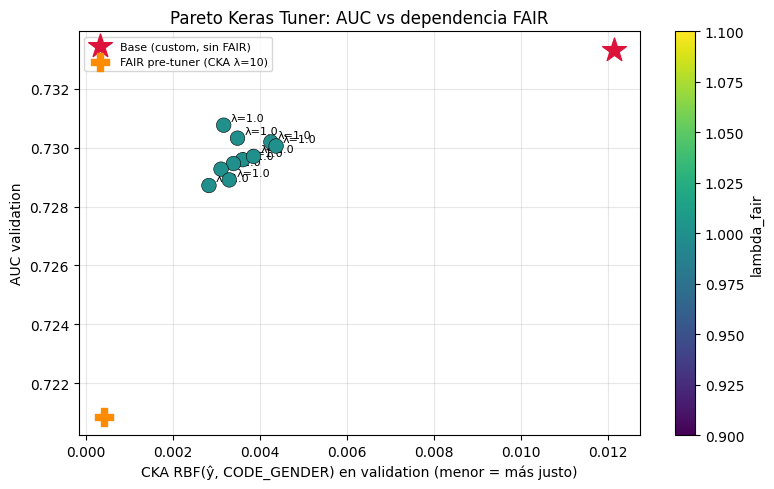

In [ ]:
# ------------------------------------------------------------
# Pareto del tuner a partir de las mejores configuraciones
# ------------------------------------------------------------
K_PARETO = min(10, len(tuner.oracle.trials))
best_hps_list = tuner.get_best_hyperparameters(K_PARETO)
best_models_list = tuner.get_best_models(K_PARETO)

pareto_rows = []
for rank, (hp_i, mdl) in enumerate(zip(best_hps_list, best_models_list)):
    proba_v = mdl.predict(val_inputs_cb, batch_size=1024, verbose=0).ravel()
    pareto_rows.append(
        {
            "rank": rank,
            "lambda_fair": hp_i.get("lambda_fair"),
            "n_layers": hp_i.get("n_layers"),
            "units": hp_i.get("units"),
            "dropout": hp_i.get("dropout"),
            "lr": hp_i.get("lr"),
            "val_auc": roc_auc_score(y_val_np, proba_v),
            "val_pearson_sq": compute_pearson_sq(proba_v, s_val_np),
            "val_cka_rbf": compute_cka_rbf_np(proba_v, s_val_np, gamma=PRINCIPAL_GAMMA),
        }
    )

tuner_trials_df = pd.DataFrame(pareto_rows)
tuner_trials_df.to_csv(OUTPUT_DIR / "tuner_trials.csv", index=False)
print("Top configuraciones del tuner (recalculadas en validation):")
display(tuner_trials_df)

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    tuner_trials_df["val_cka_rbf"],
    tuner_trials_df["val_auc"],
    c=tuner_trials_df["lambda_fair"],
    cmap="viridis",
    s=110,
    zorder=5,
    edgecolor="k",
    linewidth=0.4,
)
plt.colorbar(sc, ax=ax, label="lambda_fair")
for _, r in tuner_trials_df.iterrows():
    ax.annotate(f"λ={r['lambda_fair']}", (r["val_cka_rbf"], r["val_auc"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8)

# Referencias en métricas de VALIDATION (consistentes con los puntos del tuner).
ax.scatter([base_metrics["val_cka_rbf"]], [base_metrics["val_auc"]],
           marker="*", s=320, color="crimson", zorder=6, label="Base (custom, sin FAIR)")
principal_val_auc = roc_auc_score(y_val_np, proba_val)
principal_val_cka = compute_cka_rbf_np(proba_val, s_val_np, gamma=PRINCIPAL_GAMMA)
ax.scatter([principal_val_cka], [principal_val_auc],
           marker="P", s=160, color="darkorange", zorder=6, label="FAIR pre-tuner (CKA λ=10)")

ax.set_xlabel("CKA RBF(ŷ, CODE_GENDER) en validation (menor = más justo)")
ax.set_ylabel("AUC validation")
ax.set_title("Pareto Keras Tuner: AUC vs dependencia FAIR")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pareto_tuner.png", dpi=120, bbox_inches="tight")
plt.show()

## Modelo tuneado final y tabla comparativa

Reentrenamos de forma reproducible la mejor configuración encontrada por el tuner (con el objetivo combinado y `restore_best_weights`) y la evaluamos en **test**. La tabla resume tres modelos sobre test:

- **base custom**: arquitectura con `DebtBurdenLayer` pero sin FAIR;
- **FAIR pre-tuner**: `CKA RBF`, `λ = 10` seleccionado manualmente;
- **FAIR tuneado**: mejor configuración de Keras Tuner.

El test se usa únicamente para reportar; la selección se hizo en validación.

In [ ]:
# ------------------------------------------------------------
# Reentrenamiento reproducible del mejor modelo tuneado + evaluación
# ------------------------------------------------------------
best_hps = best_hps_list[0]
print("Mejores hiperparámetros encontrados por el tuner:")
for key, value in best_hps.values.items():
    print(f"  {key}: {value}")

keras.utils.set_random_seed(RANDOM_STATE)
tuned_model = build_tunable_fair_model(best_hps)
tuned_history = tuned_model.fit(
    x=train_inputs_cb,
    y=y_train_combined,
    validation_data=(val_inputs_cb, y_val_combined),
    # El peso de clase ya está en y_*_combined (no usar sample_weight aquí).
    epochs=EPOCHS_FAIR,
    batch_size=BATCH_SIZE_FAIR,
    callbacks=[
        CombinedFairObjective(val_inputs_cb, y_val_np, s_val_np, selection_weight=SELECTION_WEIGHT),
        keras.callbacks.EarlyStopping(
            monitor="val_combined", mode="max", patience=35,
            restore_best_weights=True, verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5,
            patience=10, min_lr=1e-5, verbose=0,
        ),
    ],
    verbose=0,
)

proba_train_tuned = _predict_proba(tuned_model, Xs_train, Xf_train)
proba_val_tuned = _predict_proba(tuned_model, Xs_val, Xf_val)
proba_test_tuned = _predict_proba(tuned_model, Xs_test, Xf_test)

tuned_test_metrics = evaluate_all(y_test_np, proba_test_tuned, s_test_np, cka_gamma=PRINCIPAL_GAMMA)
tuned_model.save(OUTPUT_DIR / "tuned_fair_model.keras")
print("\nGuardado: outputs/tuned_fair_model.keras")

# Tabla comparativa en test: base custom / FAIR pre-tuner / FAIR tuneado.
comparison_cols = [
    "auc", "balanced_accuracy", "f1_class_1",
    "pearson_sq", "cka_rbf",
    "mean_pred_gap_abs", "predicted_positive_rate_gap_abs",
]


def _row_from_metrics(name, metrics):
    return {"model": name, **{c: metrics[c] for c in comparison_cols}}


comparison_test_df = pd.DataFrame(
    [
        _row_from_metrics("base_custom_no_fair", base_test_metrics),
        _row_from_metrics("fair_pre_tuner_cka_l10", principal_test_metrics),
        _row_from_metrics("fair_tuned_hyperband", tuned_test_metrics),
    ]
)
comparison_test_df.to_csv(OUTPUT_DIR / "comparison_base_pre_post.csv", index=False)
print("\nComparativa en test (base / FAIR pre-tuner / FAIR tuneado):")


def _highlight_best(df):
    """Resalta en verde el mejor valor de cada métrica (mayor utilidad, menor dependencia/gap)."""
    higher_better = ["auc", "balanced_accuracy", "f1_class_1"]
    lower_better = ["pearson_sq", "cka_rbf", "mean_pred_gap_abs", "predicted_positive_rate_gap_abs"]
    styler = (
        df.style
        .format({c: "{:.5f}" for c in comparison_cols})
        .highlight_max(subset=higher_better, color="#b7e4c7")
        .highlight_min(subset=lower_better, color="#b7e4c7")
        .set_caption("Verde = mejor valor por columna (utilidad alta / dependencia y gap bajos)")
    )
    return styler


try:
    display(_highlight_best(comparison_test_df))
except Exception:
    # Fallback por si el entorno no renderiza Styler (p.ej. exportación a PDF plano).
    display(comparison_test_df.round(5))

# Auditoría por grupo del modelo tuneado.
tuned_group_report_test, tuned_group_gaps_test = fairness_group_report(
    y_test_np, proba_test_tuned, s_test_np
)
print("Auditoría por grupo del modelo tuneado en test:")
display(tuned_group_report_test.round(5))

Mejores hiperparámetros encontrados por el tuner:
  n_layers: 2
  units: 128
  dropout: 0.2
  lr: 0.0033137745378583987
  lambda_fair: 1.0
  tuner/epochs: 50
  tuner/initial_epoch: 17
  tuner/bracket: 3
  tuner/round: 3
  tuner/trial_id: 0047

Guardado: outputs/tuned_fair_model.keras

Comparativa en test (base / FAIR pre-tuner / FAIR tuneado):


,model,auc,balanced_accuracy,f1_class_1,pearson_sq,cka_rbf,mean_pred_gap_abs,predicted_positive_rate_gap_abs
0,base_custom_no_fair,0.73656,0.67204,0.25306,0.01158,0.01443,0.03930,0.08666
1,fair_pre_tuner_cka_l10,0.72556,0.66708,0.24747,0.00036,0.00094,0.00634,0.02037
2,fair_tuned_hyperband,0.73451,0.67368,0.25178,0.00264,0.00391,0.01953,0.04725


Auditoría por grupo del modelo tuneado en test:


,CODE_GENDER,n,target_rate,mean_pred_proba,predicted_positive_rate,auc,recall_class_1,precision_class_1
0,0,20958,0.10158,0.44370,0.37690,0.73345,0.68342,0.1842
1,1,40544,0.06995,0.42418,0.32964,0.73192,0.65127,0.1382


# Fase 3 — Reevaluación de la incertidumbre (POST-tuner)

Repetimos exactamente el mismo pipeline de incertidumbre (modelo de error + MC Dropout) sobre el **modelo tuneado**, y comparamos con el modelo principal PRE-tuner. El objetivo es comprobar si la búsqueda de arquitectura cambia el perfil de incertidumbre y si se mantiene la relación entre incertidumbre y calidad de las fuentes externas `EXT_SOURCE`.

MAE modelo de error POST-tuner: 0.04842 (PRE: 0.04265)
MC Dropout std media POST-tuner: 0.03625 (PRE: 0.03880)


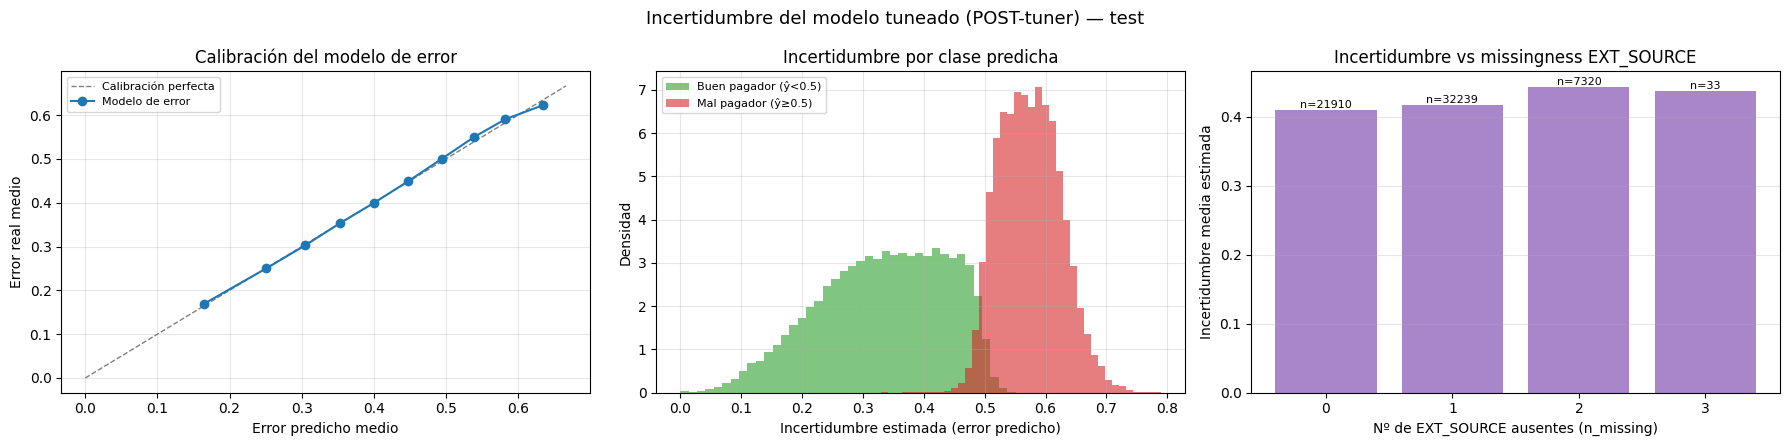

In [ ]:
# ------------------------------------------------------------
# Fase 3a: modelo de error y MC Dropout sobre el modelo tuneado
# ------------------------------------------------------------
Xunc_train_t = build_uncertainty_inputs(Xs_train, proba_train_tuned, miss_train)
Xunc_val_t = build_uncertainty_inputs(Xs_val, proba_val_tuned, miss_val)
Xunc_test_t = build_uncertainty_inputs(Xs_test, proba_test_tuned, miss_test)

err_train_t = np.abs(proba_train_tuned - y_train_np).astype("float32")
err_val_t = np.abs(proba_val_tuned - y_val_np).astype("float32")
err_test_t = np.abs(proba_test_tuned - y_test_np).astype("float32")

# Mismo criterio que en PRE-tuner: entrenamos sobre residuos de VALIDATION (out-of-sample)
# y evaluamos el MAE sobre TEST. El early stopping usa un split interno de validación.
unc_model_post, unc_hist_post = train_uncertainty_model(Xunc_val_t, err_val_t)
unc_pred_test_post = unc_model_post.predict(Xunc_test_t, batch_size=1024, verbose=0).ravel()
mae_test_post = float(np.mean(np.abs(unc_pred_test_post - err_test_t)))
unc_model_post.save(OUTPUT_DIR / "uncertainty_error_model_post.keras")

mc_mean_test_post, mc_std_test_post = mc_dropout_predict(tuned_model, Xs_test, Xf_test)

print(f"MAE modelo de error POST-tuner: {mae_test_post:.5f} (PRE: {mae_test_pre:.5f})")
print(f"MC Dropout std media POST-tuner: {mc_std_test_post.mean():.5f} (PRE: {mc_std_test_pre.mean():.5f})")

# Gráficas obligatorias para el modelo tuneado.
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
fig.suptitle("Incertidumbre del modelo tuneado (POST-tuner) — test", fontsize=13)
plot_uncertainty_calibration(err_test_t, unc_pred_test_post, "Calibración del modelo de error", ax=axes[0])
plot_uncertainty_by_predicted_class(proba_test_tuned, unc_pred_test_post, "Incertidumbre por clase predicha", ax=axes[1])
plot_uncertainty_by_missingness(unc_pred_test_post, miss_test, "Incertidumbre vs missingness EXT_SOURCE", ax=axes[2])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "uncertainty_post_tuner.png", dpi=120, bbox_inches="tight")
plt.show()

Comparación de incertidumbre PRE vs POST tuner (test):


,modelo,test_auc,test_pearson_sq,mae_modelo_error,incertidumbre_media,corr_incert_vs_nmissing,corr_error_vs_mcdropout
0,PRE-tuner (CKA λ=10),0.72556,0.00036,0.04265,0.42786,0.04052,-0.16382
1,POST-tuner (Hyperband),0.73451,0.00264,0.04842,0.41710,0.06385,0.00501


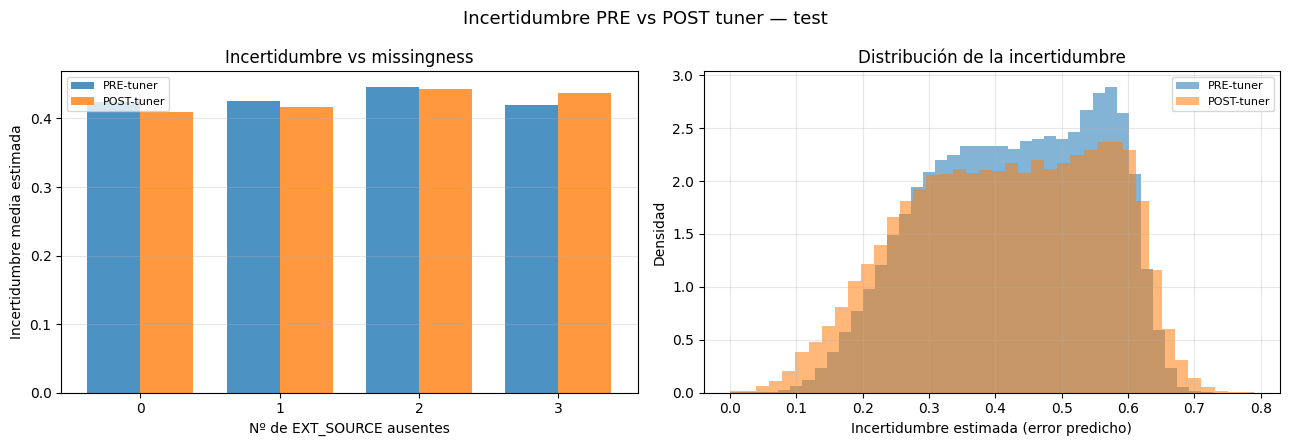

In [ ]:
# ------------------------------------------------------------
# Fase 3b: comparación PRE vs POST tuner
# ------------------------------------------------------------
n_missing_test = miss_test.sum(axis=1).astype(int)


def _uncertainty_summary(label, test_metrics, err_true, unc_pred, mc_std, mae):
    return {
        "modelo": label,
        "test_auc": test_metrics["auc"],
        "test_pearson_sq": test_metrics["pearson_sq"],
        "mae_modelo_error": mae,
        "incertidumbre_media": float(unc_pred.mean()),
        "corr_incert_vs_nmissing": float(np.corrcoef(n_missing_test, unc_pred)[0, 1]),
        "corr_error_vs_mcdropout": float(np.corrcoef(unc_pred, mc_std)[0, 1]),
    }


uncertainty_comparison_df = pd.DataFrame(
    [
        _uncertainty_summary("PRE-tuner (CKA λ=10)", principal_test_metrics,
                             err_test, unc_pred_test_pre, mc_std_test_pre, mae_test_pre),
        _uncertainty_summary("POST-tuner (Hyperband)", tuned_test_metrics,
                             err_test_t, unc_pred_test_post, mc_std_test_post, mae_test_post),
    ]
)
uncertainty_comparison_df.to_csv(OUTPUT_DIR / "uncertainty_comparison.csv", index=False)
print("Comparación de incertidumbre PRE vs POST tuner (test):")
display(uncertainty_comparison_df.round(5))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Incertidumbre PRE vs POST tuner — test", fontsize=13)

# Panel 1: incertidumbre media por n_missing, PRE vs POST.
df_nm = pd.DataFrame(
    {"n": n_missing_test, "pre": unc_pred_test_pre, "post": unc_pred_test_post}
)
grouped = df_nm.groupby("n")[["pre", "post"]].mean()
x = np.arange(len(grouped.index))
width = 0.38
axes[0].bar(x - width / 2, grouped["pre"], width, label="PRE-tuner", color="tab:blue", alpha=0.8)
axes[0].bar(x + width / 2, grouped["post"], width, label="POST-tuner", color="tab:orange", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(grouped.index)
axes[0].set_xlabel("Nº de EXT_SOURCE ausentes")
axes[0].set_ylabel("Incertidumbre media estimada")
axes[0].set_title("Incertidumbre vs missingness")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis="y")

# Panel 2: distribución global de la incertidumbre, PRE vs POST.
axes[1].hist(unc_pred_test_pre, bins=40, alpha=0.55, density=True, color="tab:blue", label="PRE-tuner")
axes[1].hist(unc_pred_test_post, bins=40, alpha=0.55, density=True, color="tab:orange", label="POST-tuner")
axes[1].set_xlabel("Incertidumbre estimada (error predicho)")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Distribución de la incertidumbre")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "uncertainty_pre_vs_post.png", dpi=120, bbox_inches="tight")
plt.show()

## Conclusiones de los puntos 3 y 4

Con estas secciones quedan cubiertas las cuatro tareas obligatorias de la práctica:

- **Punto 3 (AutoML):** Keras Tuner (Hyperband) explora arquitectura (`n_layers`, `units`, `dropout`, `lr`) y el peso de justicia `lambda_fair` (λ, dentro de la loss) a la vez. Para evitar que el tuner colapse a `λ = 0`, el objetivo de selección es combinado: `val_auc − w_sel · CKA_RBF(ŷ, s)`, con `w_sel = 2.0` fijo (peso de selección, distinto de λ). Entrenamiento, selección y reporte usan la misma métrica de dependencia (CKA RBF). La curva de Pareto muestra el coste en AUC por reducir la dependencia con el género.
- **Punto 4 (Incertidumbre):** un segundo modelo predice el error `|ŷ − y|` del modelo principal (método de Valero), validado de forma cruzada con MC Dropout. Las gráficas muestran la incertidumbre por clase predicha y, sobre todo, su relación con la calidad de las fuentes externas: a mayor número de `EXT_SOURCE` ausentes, mayor incertidumbre estimada, lo que responde directamente a la pregunta del enunciado y sugiere derivar esos casos a revisión humana.

La reevaluación PRE vs POST tuner permite comprobar que las conclusiones sobre incertidumbre son estables respecto a la arquitectura elegida.

In [ ]:
# ------------------------------------------------------------
# Resumen de artefactos generados en outputs/
# ------------------------------------------------------------
expected_artifacts = [
    "principal_fair_model.keras",
    "uncertainty_error_model_pre.keras",
    "uncertainty_error_model_post.keras",
    "tuned_fair_model.keras",
    "comparison_base_pre_post.csv",
    "uncertainty_comparison.csv",
    "tuner_trials.csv",
    "uncertainty_pre_tuner.png",
    "uncertainty_mc_dropout_pre.png",
    "pareto_tuner.png",
    "uncertainty_post_tuner.png",
    "uncertainty_pre_vs_post.png",
]

print("Artefactos de los puntos 3 y 4 en", OUTPUT_DIR.resolve())
for name in expected_artifacts:
    path = OUTPUT_DIR / name
    status = "OK" if path.exists() else "FALTA"
    size_kb = path.stat().st_size / 1024 if path.exists() else 0
    print(f"  [{status:5s}] {name} ({size_kb:.1f} KB)")

Artefactos de los puntos 3 y 4 en C:\Users\jdmar\Desktop\B4 t1\Taller_B4_T1\outputs
  [OK   ] principal_fair_model.keras (79.6 KB)
  [OK   ] uncertainty_error_model_pre.keras (58.7 KB)
  [OK   ] uncertainty_error_model_post.keras (58.7 KB)
  [OK   ] tuned_fair_model.keras (269.6 KB)
  [OK   ] comparison_base_pre_post.csv (0.6 KB)
  [OK   ] uncertainty_comparison.csv (0.4 KB)
  [OK   ] tuner_trials.csv (1.1 KB)
  [OK   ] uncertainty_pre_tuner.png (83.1 KB)
  [OK   ] uncertainty_mc_dropout_pre.png (108.4 KB)
  [OK   ] pareto_tuner.png (53.4 KB)
  [OK   ] uncertainty_post_tuner.png (83.2 KB)
  [OK   ] uncertainty_pre_vs_post.png (49.0 KB)
